# POST OPS ANALYSIS
This Jupyter notebook is intended to look at the Pre-shoot ticket responses and analyze some statistics to look for patterns and help make better AE schedules.

This is built for using the Pre Shoot Ticket CSV from Google Docs. This will need to be updated when the responses move to Airtable.

In [1]:
# import appropriate libraries
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import warnings
import textwrap

In [2]:
# check versions
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"Plotly version: {plotly.__version__}")

Pandas version: 2.2.3
Matplotlib version: 3.10.0
Seaborn version: 0.13.2
Plotly version: 6.2.0


## Load the CSV as a DataFrame
Download the Pre-shoot Ticket Response sheet from Google Sheets as a csv and save it to the "Data" folder. Then load it into this notebook as a DataFrame. 

In [3]:
pstr_df = pd.read_csv("Data/POST_OPS_TRACKING - Pre-Shoot Ticket Responses.csv")

### Explore the DataFrame
Let's check out some of the data to see what needs to be cleaned up before we proceed. 

In [4]:
# What columns currently exist
pstr_df.columns

Index(['Status', 'Series', 'Episode', 'Shoot Location_',
       'Shoot Location  (WK & CP)', 'Shoot Location', 'Shoot Dates',
       'Who is Prepping', 'Days between Footage Rcvd and Prep Needed',
       'Prep Priority', 'Ingest Email Sent Out', 'Folder created on Frame',
       'When Will Footage Be Received by Post',
       'Date Footage Actually Received', 'AE Prep Start Date',
       'AE Prep End Date', 'When Is Prep Needed By', 'Date Prep Completed',
       'Days it took to Prep', 'Shoot Start Date_', 'Shoot Start Date',
       'Shoot Start Date (WK & CP)', 'Total Number of Shoot Days_',
       'Total Number of Shoot Days', 'Total Number of Shoot Days  (WK & CP)',
       'Shoot End Date', 'Week Start', 'AE Requests',
       'If Translations Are Needed, What Language',
       'Is this currently in edit?', 'Dropped / Shipped / Uploaded',
       'Where is footage being delivered to?', 'How is it being delivered?',
       'How is Media Being Returned', 'Media', 'Drive Delivered to Pro

In [5]:
# How many unique episodes are there in the dataframe?
unique_episodes = pstr_df["Episode"].nunique()
print(f"There are {unique_episodes} unique episodes in the pre-shoot ticket dataframe.")

# How many rows have missing values for Episode Name?
missing_episode_name = pstr_df["Episode Name"].isna().sum()
print(f"There are {missing_episode_name} rows with missing values for Episode Name.")

# How many rows have missing values for Episode?
missing_episode = pstr_df["Episode"].isna().sum()
print(f"There are {missing_episode} rows with missing values for Episode.")

There are 160 unique episodes in the pre-shoot ticket dataframe.
There are 311 rows with missing values for Episode Name.
There are 2 rows with missing values for Episode.


In [6]:
# Look into shoot dates column to ensure that the data is in the correct format. 
pstr_df["Shoot Dates"].sample(15)

263    14-May-2026, 15-May-2026, 16-May-2026, 17-May-...
231    14-Apr-2026, 15-Apr-2026, 16-Apr-2026, 17-Apr-...
105                                          15-Dec-2025
236                             27-Apr-2026, 28-Apr-2026
127                                          21-Jan-2026
92                                           01-Dec-2025
1                                            15-Sep-2025
120                             15-Jan-2026, 16-Jan-2026
173                             17-Mar-2026, 18-Mar-2026
207                                          31-Mar-2026
71                              12-Nov-2025, 13-Nov-2025
47     25-Oct-2025, 26-Oct-2025, 27-Oct-2025, 28-Oct-...
315                                          02-Jul-2026
284                             11-Jun-2026, 12-Jun-2026
176                                          18-Feb-2026
Name: Shoot Dates, dtype: object

In [7]:
# Find the rows with multiple shoot dates (i.e., those that contain a comma)
rows_with_multiple_shoot_dates = pstr_df[pstr_df["Shoot Dates"].str.contains(",", na=False)]
print(f"There are {len(rows_with_multiple_shoot_dates)} rows with multiple shoot dates.")

There are 87 rows with multiple shoot dates.


In [8]:
pstr_df["Shoot Dates"].dtype

dtype('O')

In [9]:
# Do we need the Shoot Days column at all for the analysis? 

# We can use Shoot Start Date and Shoot End Date columns to calculate the shoot days.

pstr_df["Shoot Start Date"].sample(15)
pstr_df["Shoot End Date"].sample(15)
pstr_df["Shoot Start Date"].info()
pstr_df["Total Number of Shoot Days_"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 337 entries, 0 to 336
Series name: Shoot Start Date
Non-Null Count  Dtype 
--------------  ----- 
270 non-null    object
dtypes: object(1)
memory usage: 2.8+ KB
<class 'pandas.core.series.Series'>
RangeIndex: 337 entries, 0 to 336
Series name: Total Number of Shoot Days_
Non-Null Count  Dtype  
--------------  -----  
335 non-null    float64
dtypes: float64(1)
memory usage: 2.8 KB


In [10]:
# Let's look at the unique values in the Episode and Episode Name columns to see if we can identify 
# any patterns or inconsistencies that we can clean up.
unique_episode_names = pstr_df["Episode Name"].unique()
# print("Unique values in Episode Name column:")
# for episode_name in unique_episode_names:
#     print(episode_name)

unique_episodes = pstr_df["Episode"].unique()
# print("\nUnique values in Episode column:")
# for episode in unique_episodes:
#     print(episode)

series = pstr_df.groupby('Series')[['Episode', 'Episode Name']].value_counts()
series

# how many rows are missing values for Series?
missing_series = pstr_df["Series"].isna().sum()
print(f"There are {missing_series} rows with missing values for Series.")


There are 0 rows with missing values for Series.


# Function Section
Run this section for all the fun functions we'll use for analysis and plotting

### Helper Functions for Cleaning

In [11]:
def convert_date_cols(df):
    '''
    Convert columns with dates in them to datetime objects
    
    Parameters:
        df (pd.DataFrame): input dataframe that have columns with dates 
    Return: 
        df (pd.DataFrame): output dataframe with columns as proper datetime objects
    
    '''
    # Convert date columns to datetime format FIRST
    date_cols = [
        "When Will Footage Be Received by Post",
        "Date Footage Actually Received",
        "When Is Prep Needed By",
        "Date Prep Completed",
        "Shoot Dates",
        "Shoot Start Date",
        "Shoot End Date",
        "Timestamp",
    ]
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    
    return df

In [12]:
def fill_missing_dates(df):
    """
    Fill missing date fields in the post ops prep dataframe:
    - If 'Date Footage Actually Received' is missing but 'When Will Footage Be Received by Post' is populated,
      fill the date received from the expected date.
    - If 'Date Prep Completed' is missing but 'When Is Prep Needed By' is populated,
      fill the date prep completed from the expected prep needed date.
    """
    
    df = convert_date_cols(df)
    
    # fill missing 'Date Footage Actually Received' from 'When Will Footage Be Received by Post'
    mask_footage = (
        df["Date Footage Actually Received"].isna() &
        df["When Will Footage Be Received by Post"].notna()
    )
    df.loc[mask_footage, "Date Footage Actually Received"] = df.loc[mask_footage, "When Will Footage Be Received by Post"]

    # fill missing 'Date Prep Completed' from 'When Is Prep Needed By'
    mask_prep = (
        df["Date Prep Completed"].isna() &
        df["When Is Prep Needed By"].notna()
    )
    df.loc[mask_prep, "Date Prep Completed"] = df.loc[mask_prep, "When Is Prep Needed By"]

    return df

In [13]:
def fill_missing_days_to_prep(df):
    '''
    Fill in missing "Days it took to Prep"
    If days it took to prep is NA, do the math using the "Date Prep Completed" and "Date Footage Actually Received" columns
    
    Parameters: 
        df (pd.DataFrame): input dataframe
    Returns: 
        df (pd. DataFrame): output dataframe with filled in days
    '''
    # Convert to numeric first so .isna() properly detects missing values
    # (the column may still be object/string type at this point)
    if "Days it took to Prep" in df.columns:
        df["Days it took to Prep"] = pd.to_numeric(df["Days it took to Prep"], errors="coerce")

    mask = (
        df["Days it took to Prep"].isna() &
        df["Date Prep Completed"].notna() &
        df["Date Footage Actually Received"].notna()
    )
    # Date columns are already datetime (convert_date_cols ran earlier), so no need to re-wrap
    df.loc[mask, "Days it took to Prep"] = (
        df.loc[mask, "Date Prep Completed"] -
        df.loc[mask, "Date Footage Actually Received"]
    ).dt.days

    # Clip negative values to 0 (prep can't take negative days)
    df["Days it took to Prep"] = df["Days it took to Prep"].clip(lower=0)
    
    return df


In [14]:
def fill_missing_shoot_dates(df):
    """
    Fill missing 'Shoot Dates' by estimating from 'Date Footage Actually Received'.
    Uses the average gap between 'Shoot Start Date' and 'Date Footage Actually Received'
    for rows where both are populated, then subtracts that average from footage received date.

    Parameters:
        df (pd.DataFrame): input dataframe
    Returns:
        df (pd.DataFrame): dataframe with filled Shoot Dates
    """
    if (
        "Shoot Dates" not in df.columns
        or "Date Footage Actually Received" not in df.columns
    ):
        return df

    if "Shoot Start Date" in df.columns:
        df["Days Between Shoot and Footage"] = (
            df["Date Footage Actually Received"] - df["Shoot Start Date"]
        ).dt.days
        average_days_between = df["Days Between Shoot and Footage"].mean()
    else:
        average_days_between = 3  # fallback default

    mask_missing_shoot_dates = (
        df["Shoot Dates"].isna() & df["Date Footage Actually Received"].notna()
    )
    df.loc[mask_missing_shoot_dates, "Shoot Dates"] = df.loc[
        mask_missing_shoot_dates, "Date Footage Actually Received"
    ] - pd.to_timedelta(average_days_between, unit="D")

    return df


In [15]:
def keep_necessary_cols(df):
    '''
    Keep only the necessary columns for analysis. If more columns are needed, add them to the necessary_cols list. We want to keep the dataframe as lean as possible with only the necessary columns for analysis and modeling.
    
    Parameters:
        df (pd.DataFrame): input dataframe with all columns
    Returns:
        df (pd.DataFrame): output dataframe with only necessary columns for analysis and modeling
    '''
    necessary_cols = [
        "Series",
        "Episode",
        "Shoot ID",
        "Who is Prepping",
        "Shoot Dates",
        "Shoot Start Date",
        "Shoot End Date",
        "When Will Footage Be Received by Post",
        "Date Footage Actually Received",
        "When Is Prep Needed By",
        "Date Prep Completed",
        "Days it took to Prep",
        "Total Number of Shoot Days_",
        "AE Requests",
        "Timestamp",
        "Email Address",
        "Vertical"
    ]
    
    # Only keep the necessary columns that are present in the dataframe
    cols_to_keep = [col for col in necessary_cols if col in df.columns]
    
    return df[cols_to_keep]

In [16]:
def normalize_series_names(df):
    """
    Consolidate series names that refer to the same show but were entered differently.

    Parameters:
        df (pd.DataFrame): input dataframe
    Returns:
        df (pd.DataFrame): dataframe with normalized series names
    """
    if "Series" not in df.columns:
        return df

    series_name_map = {
        "Leaders with Lacqua": "Leaders with Francine Lacqua",
        "Leaders with Lacqua (Francine Lacqua Bloomberg Originals reboot)": "Leaders with Francine Lacqua",
        "Evergreen Shorts": "Shorts",
        "A Walk With (DEV)": "A Walk With",
        # Add more mappings here as needed
    }

    df["Series"] = df["Series"].replace(series_name_map)

    # Also remap BBI episodes and Vertical-based fixes from "Not Found"
    df.loc[
        df["Episode"].str.contains("BBI", na=False) & (df["Series"] == "Not Found"),
        "Series",
    ] = "Bloomberg Investigates"
    df.loc[
        df["Vertical"].str.contains("Evergreen Shorts", na=False)
        & (df["Series"] == "Not Found"),
        "Series",
    ] = "Shorts"
    df.loc[
        df["Vertical"].str.contains("Dev", na=False) & (df["Series"] == "Not Found"),
        "Series",
    ] = "Development"

    return df


In [17]:
def drop_preps_by_editor(df):
    """
    Drop rows from the post ops prep dataframe where the prep was done by the editor
    or where 'Who is Prepping' is missing (NaN).
    """
    if "Who is Prepping" in df.columns:
        # Strip whitespace and lower-case for comparison
        who = df["Who is Prepping"].dropna().astype(str).str.strip().str.lower()
        mask = (df["Who is Prepping"].notna()) & (who != "editor")
        df = df[mask].copy()  # .copy() prevents SettingWithCopyWarning on subsequent assignments
    return df


In [18]:
def clean_data(df, include_editor_preps=True, keep_only_necessary_cols=True):
    """
    Clean the dataset by converting data types and dropping redundant and unnecessary columns.
    
    Parameters:
        df (pd.DataFrame): The input dataframe to be cleaned. This should the dataframe read from the "POST_OPS_TRACKING - Pre-Shoot Ticket Responses.csv" file.
    
    Returns:
        pd.DataFrame: The cleaned dataframe.
    """
    # Work on an explicit copy so all downstream .loc assignments are safe
    df = df.copy()

    if keep_only_necessary_cols:
        df = keep_necessary_cols(df)

    if not include_editor_preps:
        # Drop rows where the prep was done by the editor or where 'Who is Prepping' is missing (NaN)
        df = drop_preps_by_editor(df)

    # Trim column names to remove leading/trailing whitespace and underscores
    df.columns = df.columns.str.strip().str.strip("_")

    # Replace string 'NA' with actual missing values (avoid inplace on a copy)
    df = df.replace("NA", pd.NA)

    # Convert date columns to datetime format FIRST
    df = convert_date_cols(df)
    
    # Normalize series names to consolidate duplicates
    df = normalize_series_names(df)

    # Fill missing dates for 'Date Footage Actually Received' / 'Date Prep Completed' from the expected dates
    df = fill_missing_dates(df)
    
    # Fill in missing values for 'Days it took to Prep' based on the difference between 'Date Prep Completed' and 'Footage actually received'
    df = fill_missing_days_to_prep(df)

    # Set 'Days it took to Prep' to 1 for same-day preps (math gives 0) and any pre-existing 0s
    if "Date Prep Completed" in df.columns and "Date Footage Actually Received" in df.columns:
        same_day_mask = (
            df["Date Prep Completed"].dt.normalize()
            == df["Date Footage Actually Received"].dt.normalize()
        )
        zero_mask = df["Days it took to Prep"] == 0
        df.loc[same_day_mask | zero_mask, "Days it took to Prep"] = 1
        
    # Fill in missing Shoot Dates based on the average gap between Shoot Start Date and Date Footage Actually Received
    df = fill_missing_shoot_dates(df)
    
    # The Reese Witherspoon epsiode is a major outlier, we'll remove it for now and add it in after we can properly adjust for it
    df = df[~df["Episode"].str.contains("Reese Witherspoon", na=False)].copy()
    
    # Convert columns that should be numeric to appropriate data types
    numeric_cols = [
        "Days between Footage Rcvd and Prep Needed",
        "Days it took to Prep",
        "Total Number of Shoot Days",
        "Time Between Submission and Shoot Start"]  
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').round().astype('Int64')
    return df


## Plotting Functions

In [19]:
def plot_hists(df):
    """
    Plot histograms for the numeric columns in the dataframe.
    
    Parameters:
        df (pd.DataFrame): The input dataframe for which to plot histograms. This should be the cleaned dataframe returned by the clean_data function.
    
    Returns:
        None: This function will display histograms for the numeric columns in the dataframe.
    """
    # Select numeric columns from the dataframe
    numeric_cols = df.select_dtypes(include=['number']).columns
    
    # Set up the plotting area
    num_cols = len(numeric_cols)
    num_rows = (num_cols + 2) // 3  # Calculate number of rows needed for 3 columns per row
    plt.figure(figsize=(15, num_rows * 5))
    
    # Plot histograms for each numeric column
    for i, col in enumerate(numeric_cols):
        plt.subplot(num_rows, 3, i + 1)
        df[col].hist(bins=15, edgecolor='black')
        plt.title(col)
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.grid(False)
    
    plt.tight_layout()
    plt.show()

In [20]:
def plot_boxplots(df, category_col, numeric_col, color_palette):
    """
    Plot boxplots for the numeric column grouped by the categorical column.
    
    Parameters:
        df (pd.DataFrame): The input dataframe for which to plot boxplots. This should be the cleaned dataframe returned by the clean_data function.
        category_col (str): The name of the categorical column to group by.
        numeric_col (str): The name of the numeric column to plot.
        color_palette (dict): A dictionary mapping category names to colors for the boxplots.
        
    Returns:
        None: This function will display boxplots for the numeric column grouped by the categorical column.
        
    """
    plt.figure(figsize=(15, 7))
    sns.boxplot(x=category_col, y=numeric_col, data=df, palette=color_palette, hue=category_col, dodge=False)
    plt.xticks(rotation=45, ha='left')
    plt.title(f"{numeric_col} by {category_col}")
    plt.grid(False)
    plt.xlabel(category_col)
    plt.ylabel(numeric_col)
    plt.show()


In [21]:
def plot_category_hists(df, category_col, numeric_col, color_palette=None):
    """
    Plot histograms for a numeric column grouped by a categorical column.
    
    Parameters:
        df (pd.DataFrame): The input dataframe for which to plot histograms. This should be the cleaned dataframe returned by the clean_data function.
        category_col (str): The name of the categorical column to group by.
        numeric_col (str): The name of the numeric column to plot.
        color_palette (dict, optional): A dictionary mapping category names to colors for the histograms. Defaults to None.
    
    Returns:
        None: This function will display histograms for the numeric column grouped by the categorical column.
    """
    categories = df[category_col].unique()
    num_categories = len(categories)
    num_rows = (num_categories + 2) // 3  # Calculate number of rows needed for 3 columns per row
    plt.figure(figsize=(15, num_rows * 5))
    
    for i, category in enumerate(categories):
        plt.subplot(num_rows, 3, i + 1)
        df[df[category_col] == category][numeric_col].hist(bins=10, edgecolor='black')
        plt.title(f"{numeric_col} - {category}")
        plt.xlabel(numeric_col)
        plt.ylabel('Frequency')
        plt.grid(False)
        if color_palette and category in color_palette:
            plt.gca().patch.set_facecolor(color_palette[category])
            
    plt.tight_layout()
    plt.show()

In [22]:
def plot_barplots(df, category_col, numeric_col, color_palette):
    """
    Plot bar plots for the numeric column grouped by the categorical column.
    
    Parameters:
        df (pd.DataFrame): The input dataframe for which to plot bar plots. This should be the cleaned dataframe returned by the clean_data function.
        category_col (str): The name of the categorical column to group by.
        numeric_col (str): The name of the numeric column to plot.
        color_palette (dict): A dictionary mapping category names to colors for the bar plots.
    Returns:
        None: This function will display bar plots for the numeric column grouped by the categorical column.
    """
    plt.figure(figsize=(15, 7))
    sns.barplot(x=category_col, y=numeric_col, data=df, hue='Series', palette=color_palette)
    plt.xticks(rotation=45, ha='right')
    plt.title(f"{numeric_col} by {category_col}")
    plt.grid(False)
    plt.xlabel(category_col)
    plt.ylabel(numeric_col)
    plt.show()

In [23]:
def plotly_barplots(df, category_col, numeric_col, color_palette):
    """
    Plot interactive bar plots using Plotly for the numeric column grouped by the categorical column.
    
    Parameters:
        df (pd.DataFrame): The input dataframe for which to plot bar plots. This should be the cleaned dataframe returned by the clean_data function.
        category_col (str): The name of the categorical column to group by.
        numeric_col (str): The name of the numeric column to plot.
        color_palette (dict): A dictionary mapping category names to colors for the bar plots.
    
    Returns:
        plotly.graph_objects.Figure: The Plotly figure object representing the bar plot.
    """
    fig = px.bar(
        df,
        x=category_col,
        y=numeric_col,
        color=category_col,
        color_discrete_map=color_palette,
        hover_data=[numeric_col],
    )
    
    fig.update_traces(texttemplate="%{y:.2f}", textposition="outside")
    
    fig.update_layout(
        xaxis_title=category_col,
        yaxis_title=numeric_col,
        title=f"{numeric_col} by {category_col}",
        uniformtext_minsize=8,
        uniformtext_mode="hide",
        showlegend=False,
        xaxis_tickangle=-45,
        width=1200, 
        height=600,
    )
    return fig

## Define a show color palette to use for all plots for consistency

In [24]:
# Update this palette if a new show is added to the dataset. 
# The colors are chosen to be visually distinct for each show.

show_color_palette = {
    "A Walk With": "#bcbd22",
    "Bloomberg Investigates": "#1f77b4",
    "Development": "#17becf",
    "Leaders with Francine Lacqua": "#d62728",
    "Posthuman": "#9467bd",
    "Primer": "#8c564b",
    "Shorts": "#e377c2",
    "The Circuit": "#ff7f0e",
    "The Deal": "#2ca02c",
    "Weekly & Cross Platform Videos": "#7f7f7f",
    "Not Found": "#c7c7c7", 
    "Zero Podcast Mishal Husain": "#e377c2",
    "Microdoc": "#6a17cf",
    "The Context": "#d62728",
    "Weekly": "#9467bd",
    "Modern Leaders": "#bcbd22",
    "Power Players - F1": "#1f77b4",
    "Leaders with Lacqua": "#17becf",
    "Francine Lacqua Podcast": "#d62728",
    "Bullish": "#8c564b",
    "A Walk With (DEV)": "#bcbd22",
    "New Economy Vodcast": "#1f77b4",
    "Leaders with Lacqua (Francine Lacqua Bloomberg Originals reboot)": "#17becf",
    "Evergreen Shorts": "#d62728",
}


# Start some Exploratory analysis

In [25]:
# clean_df will include all tickets, including those prepped by the editor
clean_df = clean_data(pstr_df, include_editor_preps=True, keep_only_necessary_cols=True)
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 337 entries, 0 to 336
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Series                                 337 non-null    object        
 1   Episode                                335 non-null    object        
 2   Shoot ID                               328 non-null    object        
 3   Who is Prepping                        305 non-null    object        
 4   Shoot Dates                            330 non-null    datetime64[ns]
 5   Shoot Start Date                       269 non-null    datetime64[ns]
 6   Shoot End Date                         335 non-null    datetime64[ns]
 7   When Will Footage Be Received by Post  303 non-null    datetime64[ns]
 8   Date Footage Actually Received         303 non-null    datetime64[ns]
 9   When Is Prep Needed By                 296 non-null    datetime64

### Initial issues: 

- There are only 269 of 337 shoot start dates. 


In [26]:
no_shoot_start_date = clean_df[clean_df["Shoot Start Date"].isna()]
no_shoot_start_date_count = len(no_shoot_start_date)
print(f"There are {no_shoot_start_date_count} rows with missing Shoot Start Date.")
no_shoot_start_date_series = no_shoot_start_date["Series"].value_counts()
print("Count of missing Shoot Start Date by Series:")   
print(no_shoot_start_date_series)

There are 68 rows with missing Shoot Start Date.
Count of missing Shoot Start Date by Series:
Series
Microdoc                      49
The Context                    8
A Walk With                    8
Not Found                      2
Zero Podcast Mishal Husain     1
Name: count, dtype: int64


These series with missing start dates typically don't fill out tickets at all, so we can safely move forward with the analysis. 

In [27]:
# Diagnostic: check for any remaining 0s in 'Days it took to Prep' after cleaning
zeros = clean_df[clean_df["Days it took to Prep"] == 0]
print(f"Rows with 0 Days it took to Prep: {len(zeros)}")
if len(zeros) > 0:
    print(zeros[["Episode", "Date Footage Actually Received", "Date Prep Completed", "Days it took to Prep"]].to_string())


Rows with 0 Days it took to Prep: 0


In [28]:
clean_df.head()

,Series,Episode,Shoot ID,Who is Prepping,Shoot Dates,Shoot Start Date,Shoot End Date,When Will Footage Be Received by Post,Date Footage Actually Received,When Is Prep Needed By,Date Prep Completed,Days it took to Prep,Total Number of Shoot Days,AE Requests,Timestamp,Email Address,Vertical,Days Between Shoot and Footage
0,Bloomberg Investigates,OG_BBI_027_Immigration,"OG_BBI_027_Immigration_Portland, OR_14Sep2025",Nancy,2025-09-14,2025-09-14,2025-09-14,2025-10-14,2025-10-20,2025-10-29,2025-10-23,3,1,"Stringouts, Transcripts",2025-10-07 14:16:54,a.avila00@gmail.com,Long Form,36.0
1,Shorts,ponzi,ponzi_NYC_15Sep2025,NaN,2025-09-15,2025-09-15,2025-09-15,2025-09-17,2025-09-17,2025-09-18,2025-09-19,2,1,"Stringouts, Transcripts",2025-09-16 16:03:14,pcourtien1@bloomberg.net,Evergreen Shorts,2.0
2,The Circuit,OG_CIR_033_Snap,OG_CIR_033_Snap_NYC_16Sep2025,NaN,2025-09-16,2025-09-16,2025-09-16,2025-09-17,2025-09-17,2025-09-19,2025-09-19,2,1,"Stringouts, Transcripts",2025-09-16 16:24:18,scardone5@bloomberg.net,Long Form,1.0
3,Shorts,ponzi,ponzi_NY_17Sep2025,NaN,2025-09-17,2025-09-17,2025-09-17,2025-09-17,2025-09-17,2025-09-22,2025-09-22,5,1,"Stringouts, Transcripts",2025-09-17 11:45:43,jrattee@bloomberg.net,Evergreen Shorts,0.0
4,Bloomberg Investigates,OG_BBI_027_Immigration,"OG_BBI_027_Immigration_Portland, OR_19Sep2025",Nancy,2025-09-19,2025-09-19,2025-09-19,2025-10-14,2025-10-20,2025-10-29,2025-10-23,3,1,"Stringouts, Transcripts",2025-10-07 14:18:16,a.avila00@gmail.com,Long Form,31.0


### Check that cleaning working as expected

Look into why there are missing records from several date fields: 
When will footage be received by post:

In [29]:
print(f"Number of entries missing for When Will Footage be Received By Post: {clean_df['When Will Footage Be Received by Post'].isna().sum()}")
print(f"Number of entries missing for Date Footage Actually Received: {clean_df['Date Footage Actually Received'].isna().sum()}")
print(f"Number of entries missing for When Is Prep Needed By: {clean_df['When Is Prep Needed By'].isna().sum()}")
print(f"Number of entries missing for Date Prep Completed: {clean_df['Date Prep Completed'].isna().sum()}")
print(f"Number of entries missing for Date Prep Completed: {clean_df['Date Prep Completed'].isna().sum()}")
print(f"Number of entries missing for Days it took to Prep: {clean_df['Days it took to Prep'].isna().sum()}")

Number of entries missing for When Will Footage be Received By Post: 34
Number of entries missing for Date Footage Actually Received: 34
Number of entries missing for When Is Prep Needed By: 41
Number of entries missing for Date Prep Completed: 41
Number of entries missing for Date Prep Completed: 41
Number of entries missing for Days it took to Prep: 41


These numbers are likely due to editor prepping, so let's grab another dataframe without those records. 

In [30]:
# post_ops_prep_df will exclude tickets prepped by the editor
post_ops_prep_df = clean_data(pstr_df, include_editor_preps=False, keep_only_necessary_cols=True)

In [31]:
print(f"Number of entries missing for When Will Footage be Received By Post: {post_ops_prep_df['When Will Footage Be Received by Post'].isna().sum()}")
print(f"Number of entries missing for Date Footage Actually Received: {post_ops_prep_df['Date Footage Actually Received'].isna().sum()}")
print(f"Number of entries missing for When Is Prep Needed By: {post_ops_prep_df['When Is Prep Needed By'].isna().sum()}")
print(f"Number of entries missing for Date Prep Completed: {post_ops_prep_df['Date Prep Completed'].isna().sum()}")
print(f"Number of entries missing for Days it took to Prep: {post_ops_prep_df['Days it took to Prep'].isna().sum()}")

Number of entries missing for When Will Footage be Received By Post: 3
Number of entries missing for Date Footage Actually Received: 3
Number of entries missing for When Is Prep Needed By: 4
Number of entries missing for Date Prep Completed: 4
Number of entries missing for Days it took to Prep: 4


Technically after cleaning, these should be 0, but this is likely the 4 most recent entries that have nobody assigned yet or are in process when the data was pulled. 

In [32]:
# Show rows where 'When Will Footage Be Received by Post' is missing
missing_footage_received = post_ops_prep_df[
    post_ops_prep_df["When Will Footage Be Received by Post"].isna()
]

# Show rows where 'Date Footage Actually Received' is missing
missing_date_received = post_ops_prep_df[
    post_ops_prep_df["Date Footage Actually Received"].isna()
]

# Show rows where 'When Is Prep Needed By' is missing
missing_prep_needed = post_ops_prep_df[post_ops_prep_df["When Is Prep Needed By"].isna()]

# Show rows where 'Date Prep Completed' is missing
missing_prep_completed = post_ops_prep_df[post_ops_prep_df["Date Prep Completed"].isna()]

# Show rows where 'Days it took to Prep' is missing
missing_days_to_prep = post_ops_prep_df[post_ops_prep_df["Days it took to Prep"].isna()]


In [33]:
# Confirm that the 3 records with missing date received are the most recent records that hasn't been completed yet. 
pd.set_option("display.max_columns", None)
missing_date_received


,Series,Episode,Shoot ID,Who is Prepping,Shoot Dates,Shoot Start Date,Shoot End Date,When Will Footage Be Received by Post,Date Footage Actually Received,When Is Prep Needed By,Date Prep Completed,Days it took to Prep,Total Number of Shoot Days,AE Requests,Timestamp,Email Address,Vertical,Days Between Shoot and Footage
280,Bloomberg Investigates,OG_BBI_043_Cyberbullies,OG_BBI_043_Cyberbullies_San Francisco_03Jun2026,Donovan,2026-06-03,2026-06-03,2026-06-03,NaT,NaT,NaT,NaT,<NA>,1,"Stringouts, Transcripts For Interview, Transcr...",2026-05-21 09:40:54,TBD,Long Form,NaN
331,Bloomberg Investigates,OG_BBI_050_SazanIsland,OG_BBI_050_SazanIsland_Albania Tirana_20Jun2026,Nas,2026-06-20,2026-06-20,2026-06-20,NaT,NaT,NaT,NaT,<NA>,1,"Transcripts For Interview, Transcripts For Ver...",2026-06-22 10:07:52,laughlin.laurent@gmail.com,Long Form,NaN
332,Bloomberg Investigates,OG_BBI_050_SazanIsland,OG_BBI_050_SazanIsland_Tirana_25Jun2026,Nas,2026-06-25,2026-06-25,2026-06-25,NaT,NaT,NaT,NaT,<NA>,1,"Transcripts For Verite, Translations",2026-06-25 11:40:24,laughlin.laurent@gmail.com,Long Form,NaN


In [34]:
check_days_math = clean_df[clean_df["Days it took to Prep"] >= 1]
check_days_math.head()

,Series,Episode,Shoot ID,Who is Prepping,Shoot Dates,Shoot Start Date,Shoot End Date,When Will Footage Be Received by Post,Date Footage Actually Received,When Is Prep Needed By,Date Prep Completed,Days it took to Prep,Total Number of Shoot Days,AE Requests,Timestamp,Email Address,Vertical,Days Between Shoot and Footage
0,Bloomberg Investigates,OG_BBI_027_Immigration,"OG_BBI_027_Immigration_Portland, OR_14Sep2025",Nancy,2025-09-14,2025-09-14,2025-09-14,2025-10-14,2025-10-20,2025-10-29,2025-10-23,3,1,"Stringouts, Transcripts",2025-10-07 14:16:54,a.avila00@gmail.com,Long Form,36.0
1,Shorts,ponzi,ponzi_NYC_15Sep2025,NaN,2025-09-15,2025-09-15,2025-09-15,2025-09-17,2025-09-17,2025-09-18,2025-09-19,2,1,"Stringouts, Transcripts",2025-09-16 16:03:14,pcourtien1@bloomberg.net,Evergreen Shorts,2.0
2,The Circuit,OG_CIR_033_Snap,OG_CIR_033_Snap_NYC_16Sep2025,NaN,2025-09-16,2025-09-16,2025-09-16,2025-09-17,2025-09-17,2025-09-19,2025-09-19,2,1,"Stringouts, Transcripts",2025-09-16 16:24:18,scardone5@bloomberg.net,Long Form,1.0
3,Shorts,ponzi,ponzi_NY_17Sep2025,NaN,2025-09-17,2025-09-17,2025-09-17,2025-09-17,2025-09-17,2025-09-22,2025-09-22,5,1,"Stringouts, Transcripts",2025-09-17 11:45:43,jrattee@bloomberg.net,Evergreen Shorts,0.0
4,Bloomberg Investigates,OG_BBI_027_Immigration,"OG_BBI_027_Immigration_Portland, OR_19Sep2025",Nancy,2025-09-19,2025-09-19,2025-09-19,2025-10-14,2025-10-20,2025-10-29,2025-10-23,3,1,"Stringouts, Transcripts",2025-10-07 14:18:16,a.avila00@gmail.com,Long Form,31.0


## Some basic exploration for prep
Start with days it took for prep for the Post Refresh after January 1, 2026

Remember, `clean_df` includes editor preps; `post_ops_prep_df` does not. 

In [35]:
jan_to_current = clean_df[
    (clean_df["Date Footage Actually Received"] >= "2026-01-01")
    & (clean_df["Date Footage Actually Received"] <= pd.Timestamp.now())
] .copy()

jan_to_current.groupby("Series")["Days it took to Prep"].describe()

,count,mean,std,min,25%,50%,75%,max
Series,,,,,,,,
A Walk With,6.0,3.333333,3.011091,1.0,1.0,2.0,5.25,8.0
Bloomberg Investigates,48.0,3.854167,2.909921,1.0,1.0,3.0,6.0,12.0
Development,13.0,2.538462,2.066212,1.0,1.0,2.0,4.0,8.0
Francine Lacqua,2.0,5.5,0.707107,5.0,5.25,5.5,5.75,6.0
Francine Lacqua vodcast,1.0,4.0,<NA>,4.0,4.0,4.0,4.0,4.0
Leaders with Francine Lacqua,3.0,5.0,5.291503,1.0,2.0,3.0,7.0,11.0
Microdoc,33.0,3.454545,4.031834,1.0,1.0,2.0,4.0,20.0
Not Found,2.0,3.0,2.828427,1.0,2.0,3.0,4.0,5.0
Post Human,12.0,6.5,2.746899,1.0,5.0,7.0,7.0,13.0


In [36]:
# Combine all series with Francine Lacqua into a single category
for key in list(jan_to_current["Series"].unique()):
    if "Lacqua" in key:
        jan_to_current.loc[jan_to_current["Series"] == key, "Series"] = "Francine Lacqua"


In [49]:
for key in list(post_since_jan["Series"].unique()):
    if "Lacqua" in key:
        post_since_jan.loc[post_since_jan["Series"] == key, "Series"] = "Francine Lacqua"

In [50]:
# Drop The Context, Weekly
jan_to_current = jan_to_current[
    ~jan_to_current["Series"].isin(["The Context", "Weekly"])
]

post_since_jan = post_since_jan[
    ~post_since_jan["Series"].isin(["The Context", "Weekly"])
]

In [51]:
# Correct Post Human to Posthuman
jan_to_current.loc[jan_to_current["Series"] == "Post Human", "Series"] = "Posthuman"
post_since_jan.loc[post_since_jan["Series"] == "Post Human", "Series"] = "Posthuman"

In [52]:
# Confirm that all records take at least 1 day to prep!
pd.set_option('display.max_columns', None)
jan_to_current[jan_to_current['Days it took to Prep'] == 0]
post_since_jan[post_since_jan['Days it took to Prep'] == 0]

,Series,Episode,Shoot ID,Who is Prepping,Shoot Dates,Shoot Start Date,Shoot End Date,When Will Footage Be Received by Post,Date Footage Actually Received,When Is Prep Needed By,Date Prep Completed,Days it took to Prep,Total Number of Shoot Days,AE Requests,Timestamp,Email Address,Vertical,Days Between Shoot and Footage


# EDA Questions from Steph and Rosalie

#### What is the total amount of tickets we received in from Jan 2026 to now?

In [53]:
jan_to_current.info()

<class 'pandas.core.frame.DataFrame'>
Index: 182 entries, 111 to 323
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Series                                 182 non-null    object        
 1   Episode                                181 non-null    object        
 2   Shoot ID                               181 non-null    object        
 3   Who is Prepping                        179 non-null    object        
 4   Shoot Dates                            182 non-null    datetime64[ns]
 5   Shoot Start Date                       147 non-null    datetime64[ns]
 6   Shoot End Date                         182 non-null    datetime64[ns]
 7   When Will Footage Be Received by Post  182 non-null    datetime64[ns]
 8   Date Footage Actually Received         182 non-null    datetime64[ns]
 9   When Is Prep Needed By                 176 non-null    datetime64[ns

In [54]:
# list all the datecolumns in the dataframe
date_columns = [col for col in jan_to_current.columns if jan_to_current[col].dtypes == 'datetime64[ns]']
date_columns

['Shoot Dates',
 'Shoot Start Date',
 'Shoot End Date',
 'When Will Footage Be Received by Post',
 'Date Footage Actually Received',
 'When Is Prep Needed By',
 'Date Prep Completed',
 'Timestamp']

In [55]:
# First, check the initial date for the dataframe to ensure we have captured all of 2026:
print(f"Minimum Shoot Start Date: {jan_to_current['Shoot Start Date'].min()}")
print(f"Minimum Shoot End Date: {jan_to_current['Shoot End Date'].min()}")
print(f"Minimum When Will Footage Be Received by Post: {jan_to_current['When Will Footage Be Received by Post'].min()}")
print(f"Minimum Date Footage Actually Received: {jan_to_current['Date Footage Actually Received'].min()}")
print(f"Minimum When Is Prep Needed By: {jan_to_current['When Is Prep Needed By'].min()}")
print(f"Minimum Date Prep Completed: {jan_to_current['Date Prep Completed'].min()}")


Minimum Shoot Start Date: 2025-12-19 00:00:00
Minimum Shoot End Date: 2025-12-20 00:00:00
Minimum When Will Footage Be Received by Post: 2025-12-22 00:00:00
Minimum Date Footage Actually Received: 2026-01-09 00:00:00
Minimum When Is Prep Needed By: 2026-01-05 00:00:00
Minimum Date Prep Completed: 2026-01-09 00:00:00


In [56]:
# total number of tickets received since Feb 27th, 2025
total_tickets = len(jan_to_current)

print(
    f"Total number of tickets received since {jan_to_current['Timestamp'].min().strftime('%B %d, %Y')} (as of {jan_to_current['Timestamp'].max().strftime('%B %d, %Y')}): {total_tickets}"
)

post_since_jan = post_ops_prep_df[
    (post_ops_prep_df["Date Footage Actually Received"] >= "2026-01-01")
    & (post_ops_prep_df["Date Footage Actually Received"] <= pd.Timestamp.now())
] .copy()

total_post_tickets = len(post_since_jan)
print(f"Total number of tickets received since {post_since_jan['Timestamp'].min().strftime('%B %d, %Y')} (as of {post_since_jan['Timestamp'].max().strftime('%B %d, %Y')}): {total_post_tickets}")

Total number of tickets received since December 10, 2025 (as of July 01, 2026): 182
Total number of tickets received since December 10, 2025 (as of June 29, 2026): 146


#### What show did the most prep / what is the total number of preps done per series?

Note: ALL TICKETS are in the `clean_df` and tickets that went through post ops for prep are in `post_ops_prep_df`. 
ALL TICKETS since January 2026 are in `jan_to_current` and thickets that went through post ops for prep are in `post_since_jan`. For the bulk of this analysis, we will use the `post_since_jan`.

In [73]:
# Normalize just before counting (so execution order can't break it)
post_since_jan = post_since_jan.copy()
post_since_jan["Series"] = post_since_jan["Series"].astype("string").str.strip()

# Collapse all Lacqua variants into one label
post_since_jan.loc[
    post_since_jan["Series"].str.contains("lacqua", case=False, na=False), "Series"
] = "Francine Lacqua"

# Optional check
print(
    sorted(
        post_since_jan.loc[
            post_since_jan["Series"].str.contains("lacqua", case=False, na=False),
            "Series",
        ]
        .dropna()
        .unique()
    )
)


['Francine Lacqua']


In [74]:
# 1) Build counts
tickets_by_series = (
    post_since_jan.groupby("Series").size().reset_index(name="Ticket Count")
)

# 2) Drop one or more series
drop_series = ["Not Found"]  # add others if needed
tickets_by_series = tickets_by_series[~tickets_by_series["Series"].isin(drop_series)]

# 3) Sort by ticket count (highest to lowest)
tickets_by_series = tickets_by_series.sort_values(
    by="Ticket Count", ascending=False
).reset_index(drop=True)

print(tickets_by_series)


                   Series  Ticket Count
0  Bloomberg Investigates            46
1                  Shorts            27
2                Microdoc            24
3             The Circuit            11
4              Post Human            10
5             A Walk With             6
6                The Deal             6
7             Development             6
8         Francine Lacqua             5
9                  Primer             4


In [75]:
plotly_barplots(tickets_by_series, 'Series', 'Ticket Count', show_color_palette)

### Tickets by Vertical

In [66]:
# 1) Build counts
tickets_by_vertical = (
    post_since_jan.groupby("Vertical").size().reset_index(name="Ticket Count")
)

# 2) Drop one or more series
drop_series = ["Not Found"]  # add others if needed
tickets_by_vertical = tickets_by_vertical[~tickets_by_vertical["Vertical"].isin(drop_series)]

# 3) Sort by ticket count (highest to lowest)
tickets_by_vertical = tickets_by_vertical.sort_values(
    by="Ticket Count", ascending=False
).reset_index(drop=True)

print(tickets_by_vertical)


                  Vertical  Ticket Count
0                Long Form            82
1         Evergreen Shorts            34
2           Cross Platform            16
3  Weekly & Cross Platform             8
4              Development             5
5     Weekly & Development             1


In [64]:
# Cross Platform, Weekly & Cross Platform, Development, and then Weeky & Development should be split up. This is an error at the data level. 
# What shows are under Weekly & Cross Platform?

weekly_cross_platform = post_since_jan[
    post_since_jan["Vertical"] == "Weekly & Cross Platform"
]

weekly_cross_platform

,Series,Episode,Shoot ID,Who is Prepping,Shoot Dates,Shoot Start Date,Shoot End Date,When Will Footage Be Received by Post,Date Footage Actually Received,When Is Prep Needed By,Date Prep Completed,Days it took to Prep,Total Number of Shoot Days,AE Requests,Timestamp,Email Address,Vertical,Days Between Shoot and Footage
140,A Walk With,AWW_2601_debbisoo,AWW_2601_debbisoo__05Feb2026,Donovan,2026-02-05 00:00:00.000000000,NaT,2026-02-05,2026-02-06,2026-02-06,2026-02-27,2026-02-10,1,1,Broll Stringouts,2026-01-22 13:10:01,jwilkinson63@bloomberg.net,Weekly & Cross Platform,NaN
147,A Walk With,AWW_2601_bjarkeingels,AWW_2601_bjarkeingels__13Feb2026,Donovan,2026-02-13 00:00:00.000000000,NaT,2026-02-13,2026-02-17,2026-02-17,2026-02-20,2026-02-17,1,1,"Stringouts, Transcripts For Interview, Transcr...",2026-01-22 13:10:47,jwilkinson63@bloomberg.net,Weekly & Cross Platform,NaN
161,Microdoc,MDC_2603_spravato,MDC_2603_spravato__20Mar2026,Nancy,2026-03-20 00:00:00.000000000,NaT,2026-03-20,2026-03-23,2026-03-23,2026-03-25,2026-03-24,1,1,NaN,2026-03-13 11:29:45,hbaker31@bloomberg.net,Weekly & Cross Platform,NaN
165,Microdoc,MDC_2602_monopolygo,MDC_2602_monopolygo__19Mar2026,Donovan,2026-03-19 00:00:00.000000000,NaT,2026-03-19,2026-03-20,2026-03-23,2026-03-23,2026-03-24,1,1,"Stringouts, Transcripts For Interview, Transcr...",2026-03-11 11:13:28,btang59@bloomberg.net,Weekly & Cross Platform,NaN
176,A Walk With,AWW_2601_debbisoo,AWW_2601_debbisoo__18Feb2026,Donovan,2026-02-18 00:00:00.000000000,NaT,2026-02-18,2026-02-20,2026-02-23,2026-03-05,2026-03-03,8,1,NaN,2026-02-04 20:37:37,jwilkinson63@bloomberg.net,Weekly & Cross Platform,NaN
181,Microdoc,MDC_2602_energyafford,MDC_2602_energyafford__25Feb2026,Donovan,2026-02-25 04:02:22.574257429,NaT,2026-02-26,2026-03-02,2026-03-02,2026-03-07,2026-03-05,3,2,Needs Transcripts and edit prep,2026-02-19 11:57:39,rcavataro@bloomberg.net,Weekly & Cross Platform,NaN
191,Microdoc,MDC_2602_monopolygo,MDC_2602_monopolygo__09Mar2026,Donovan,2026-03-09 00:00:00.000000000,NaT,2026-03-09,2026-03-10,2026-03-10,2026-03-13,2026-03-13,3,1,"Strings, Transcripts for Interview, Transcript...",2026-03-05 12:52:08,btang59@bloomberg.net,Weekly & Cross Platform,NaN
192,Not Found,MDC_2602_pananma,MDC_2602_pananma__11Mar2026,Nancy,2026-03-11 00:00:00.000000000,NaT,2026-03-11,2026-03-11,2026-03-12,2026-03-12,2026-03-17,5,1,NaN,2026-03-09 12:11:59,kshea33@bloomberg.net,Weekly & Cross Platform,NaN


In [65]:
cross_platform = post_since_jan[post_since_jan["Vertical"] == "Cross Platform"]

cross_platform

,Series,Episode,Shoot ID,Who is Prepping,Shoot Dates,Shoot Start Date,Shoot End Date,When Will Footage Be Received by Post,Date Footage Actually Received,When Is Prep Needed By,Date Prep Completed,Days it took to Prep,Total Number of Shoot Days,AE Requests,Timestamp,Email Address,Vertical,Days Between Shoot and Footage
203,Microdoc,MDC_2603_nycferry,MDC_2603_nycferry__01Apr2026,Donovan,2026-04-01 00:00:00.000000000,NaT,2026-04-01,2026-04-01,2026-04-01,2026-04-02,2026-04-01,1,1,"Stringouts, Transcripts For Interview",2026-03-24 13:38:45,lizziecphilip@gmail.com,Cross Platform,NaN
228,Microdoc,MDC_2603_usaid_africa,MDC_2603_usaid_africa__15Apr2026,Juniper,2026-04-18 04:02:22.574257429,NaT,2026-04-16,2026-04-20,2026-04-23,2026-04-28,2026-04-28,5,2,"Stringouts, Transcripts For Interview, Transcr...",2026-04-13 12:23:17,rcavataro@bloomberg.net,Cross Platform,NaN
243,Microdoc,MDC_2604_billionaire_tax,MDC_2604_billionaire_tax__07May2026,Donovan,2026-05-07 00:00:00.000000000,NaT,2026-05-07,2026-05-05,2026-05-08,2026-05-08,2026-05-08,1,1,NaN,2026-04-27 12:12:46,hbaker31@bloomberg.net,Cross Platform,NaN
247,Microdoc,MDC_2603_usaid_africa,MDC_2603_usaid_africa__05May2026,Juniper,2026-05-05 00:00:00.000000000,NaT,2026-05-05,2026-05-05,2026-05-12,2026-05-12,2026-05-12,1,2,"Stringouts, Transcripts For Interview, Transcr...",NaT,rcavataro@bloomberg.net,Cross Platform,NaN
251,Microdoc,MDC_2603_h1b_housing,MDC_2603_h1b_housing__12May2026,Rosalie,2026-05-12 00:00:00.000000000,NaT,2026-05-12,2026-05-12,2026-05-12,2026-05-15,2026-05-15,3,1,Transcripts For Interview,2026-05-06 10:48:48,jwilkinson623@bloomberg.net,Cross Platform,NaN
252,A Walk With,AWW_2601_grainnewafer,AWW_2601_grainnewafer__08May2026,Juniper,2026-05-08 00:00:00.000000000,NaT,2026-05-08,2026-05-11,2026-05-12,2026-05-15,2026-05-15,3,1,"Stringouts, Transcripts For Interview",2026-04-01 12:12:09,Jwilkinson63@bloomberg.net,Cross Platform,NaN
253,Microdoc,MDC_2604_ice_economics,MDC_2604_ice_economics__13May2026,Rosalie,2026-05-13 00:00:00.000000000,NaT,2026-05-13,2026-05-13,2026-05-13,2026-05-13,2026-05-13,1,1,"Stringouts, Transcripts For Interview",2026-05-13 06:10:24,jrattee@bloomberg.net,Cross Platform,NaN
269,Microdoc,MDC_2605_mdc_eli_lilly,MDC_2605_mdc_eli_lilly__22May2026,Donovan,2026-05-22 00:00:00.000000000,NaT,2026-05-22,2026-05-27,2026-05-27,2026-05-29,2026-05-29,2,1,Transcripts For Interview,2026-05-27 12:39:52,hbaker31@bloomberg.net,Cross Platform,NaN
287,Microdoc,MDC_2606_cerberus,MDC_2606_cerberus__15Jun2026,Donovan,2026-06-15 00:00:00.000000000,NaT,2026-06-15,2026-06-15,2026-06-15,2026-06-19,2026-06-19,4,1,Transcripts For Interview,2026-06-04 12:56:05,jwilkinson63@bloomberg.net,Cross Platform,NaN
288,Microdoc,MDC_2604_romantasy-boom,MDC_2604_romantasy-boom__23Jun2026,Donovan,2026-06-23 00:00:00.000000000,NaT,2026-06-23,2026-06-23,2026-06-23,2026-06-29,2026-06-29,6,1,"Stringouts, Transcripts For Interview",2026-05-26 09:40:54,TBD,Cross Platform,NaN


In [66]:
# These are all mixed up; let's do some mapping on the datalevel to get the verticals correct based on the series
cross_platform_vertical_mapping = {
    "A Walk With": "Cross Platform",
    "The Context": "Cross Platform",
    "Microdoc": "Cross Platform",
}

post_since_jan["Vertical"] = post_since_jan.apply(
    lambda row: cross_platform_vertical_mapping.get(row["Series"], row["Vertical"]),
    axis=1
)

In [69]:
# 1) Build counts
tickets_by_vertical = (
    post_since_jan.groupby("Vertical").size().reset_index(name="Ticket Count")
)

# 2) Drop one or more series
drop_series = ["Not Found", "Weekly & Cross Platform", "Weekly & Development"]  # add others if needed
tickets_by_vertical = tickets_by_vertical[
    ~tickets_by_vertical["Vertical"].isin(drop_series)
]

# 3) Sort by ticket count (highest to lowest)
tickets_by_vertical = tickets_by_vertical.sort_values(
    by="Ticket Count", ascending=False
).reset_index(drop=True)

print(tickets_by_vertical)


           Vertical  Ticket Count
0         Long Form            82
1    Cross Platform            30
2  Evergreen Shorts            27
3       Development             5


In [70]:
plotly_barplots(tickets_by_vertical, 'Vertical', 'Ticket Count', show_color_palette)

### Different types of way footage was delivered

In [68]:
# post_since_jan.head()

In [69]:
# pstr_df.columns

To get the different ways footage was delivered, we need to go back to the original raw dataframe before it was cleaned. The cleaned DataFrame dropped this column!

In [70]:
cols = ['Dropped / Shipped / Uploaded',
       'Where is footage being delivered to?', 'How is it being delivered?',
       'How is Media Being Returned']

footage_delivery_methods = pstr_df[cols]
footage_delivery_methods.head()

,Dropped / Shipped / Uploaded,Where is footage being delivered to?,How is it being delivered?,How is Media Being Returned
0,Uploaded to Frame.io,NaN,NaN,Remote (Frame.io Upload)
1,Dropped at NYC Office - 731 Lexington Ave,NYC Office - 731 Lexington Ave,Drives Dropped off at Office,Drives or Cards
2,Dropped at NYC Office - 731 Lexington Ave,NYC Office - 731 Lexington Ave,Drives Dropped off at Office,Drives or Cards
3,Dropped at NYC Office - 731 Lexington Ave,NYC Office - 731 Lexington Ave,Drives Dropped off at Office,Drives or Cards
4,Uploaded to Frame.io,NaN,NaN,Remote (Frame.io Upload)


Luckily some genius at Bloomberg has already cleaned up the delivery methods for us. 
We can use the "Dropped / Shipped / Uploaded" column to analyze how footage is being returned to the production team.

There was an allowance of some short text fill in, so we need to clean up a bit of the data. Primarly we want to combine every instance of the Hong Kong office mentioned into one category.

In [71]:
mask = footage_delivery_methods["Dropped / Shipped / Uploaded"].str.contains(
    "Hong Kong", case=False, na=False
)
footage_delivery_methods = footage_delivery_methods.copy()
footage_delivery_methods.loc[mask, "Dropped / Shipped / Uploaded"] = "Dropped at Hong Kong Office"


In [73]:
# Count the number of occurrences of each unique value in the "Dropped / Shipped / Uploaded" column and get the top 5 most common methods
footage_delivery_counts = footage_delivery_methods["Dropped / Shipped / Uploaded"].value_counts().nlargest(5)
footage_delivery_counts

Dropped / Shipped / Uploaded
Uploaded to Frame.io                                      134
Dropped at NYC Office - 731 Lexington Ave                 106
Dropped at London Office - 3 Queen Victoria St, London     32
Shipped to NYC Office - 731 Lexington Ave                  19
Dropped at Hong Kong Office                                 8
Name: count, dtype: int64

In [74]:
fig = px.pie(
    names=footage_delivery_counts.index,
    values=footage_delivery_counts.values,
    title="How Footage was Delivered to Post"    
)

fig.show()

## How many countries did we shoot in?
The Post Ops Response csv was sent to AI to get the unique data. The code below is AI generated. 

In [12]:
# %pip install geopandas
# %pip install geodatasets

Map generated: world_map_shoots.png


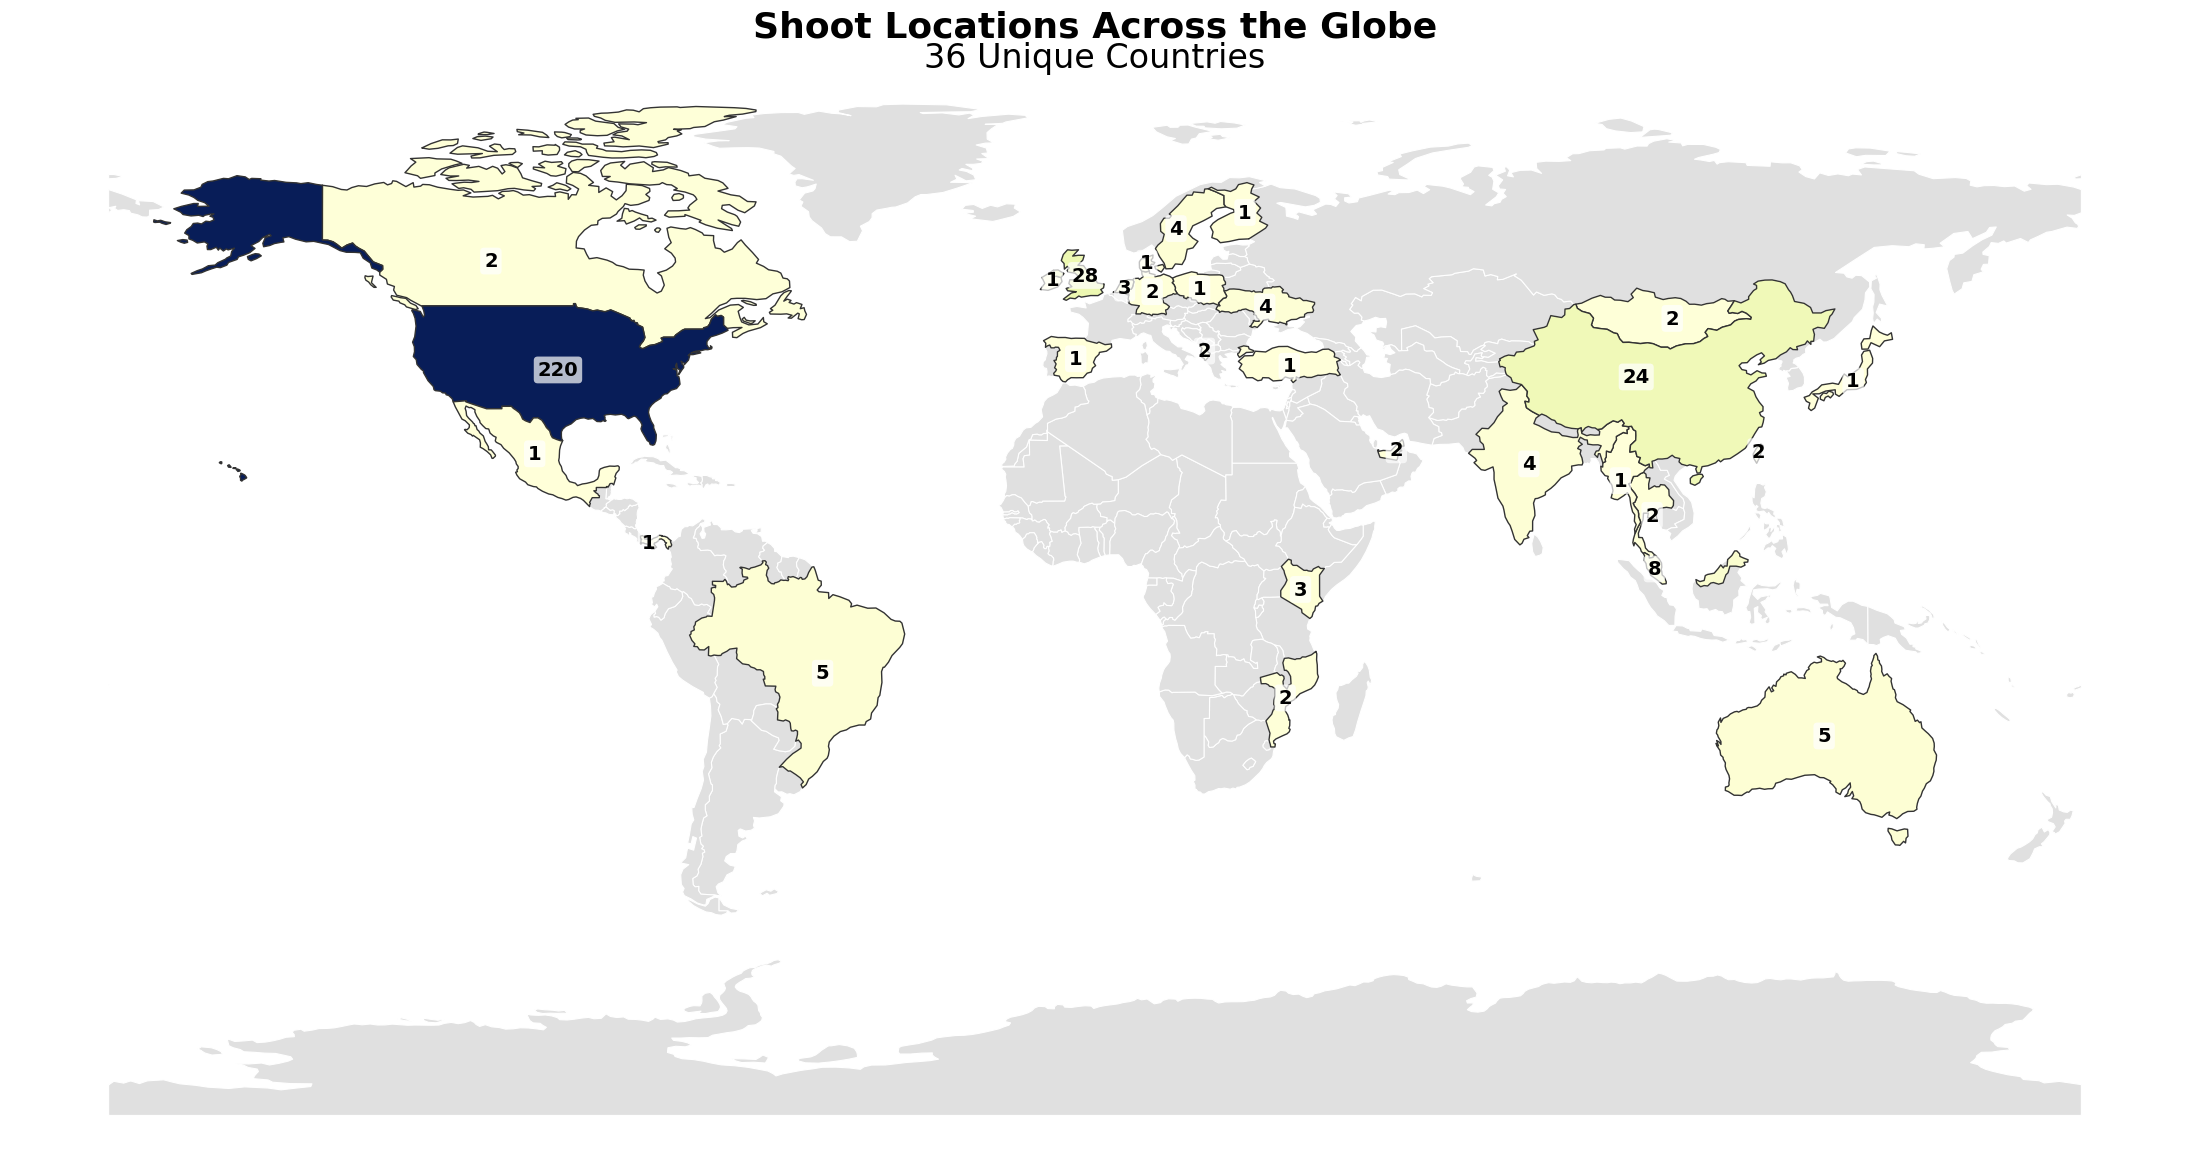

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

try:
    import geopandas as gpd
    has_gpd = True
except ImportError:
    has_gpd = False

if has_gpd:
    # Use the notebook's existing relative path convention
    df = pd.read_csv("Data/POST_OPS_TRACKING - Pre-Shoot Ticket Responses.csv")
    loc_series = df["Shoot Location_"].dropna().astype(str).str.strip()
    loc_series = loc_series[loc_series != "#REF!"]

    def get_country(loc):
        loc_lower = loc.lower()
        if "albania" in loc_lower or "tirana" in loc_lower:
            return "Albania"
        if "australia" in loc_lower or "hobart" in loc_lower:
            return "Australia"
        if "brazil" in loc_lower:
            return "Brazil"
        if "canada" in loc_lower or "toronto" in loc_lower or "vancouver" in loc_lower:
            return "Canada"
        if (
            "china" in loc_lower
            or "beijing" in loc_lower
            or "guangzhou" in loc_lower
            or "shenzhen" in loc_lower
            or "shanghai" in loc_lower
        ):
            return "China"
        if "denmark" in loc_lower:
            return "Denmark"
        if "finland" in loc_lower:
            return "Finland"
        if (
            "germany" in loc_lower
            or "frankfurt" in loc_lower
            or "stuttgart" in loc_lower
        ):
            return "Germany"
        if "hong kong" in loc_lower or "hk office" in loc_lower:
            return "China"
        if "india" in loc_lower and "indianapolis" not in loc_lower:
            return "India"
        if "ireland" in loc_lower:
            return "Ireland"
        if "japan" in loc_lower or "tokyo" in loc_lower:
            return "Japan"
        if "kenya" in loc_lower:
            return "Kenya"
        if "malaysia" in loc_lower or "kuala lumpur" in loc_lower:
            return "Malaysia"
        if "mexico" in loc_lower:
            return "Mexico"
        if "mongolia" in loc_lower:
            return "Mongolia"
        if "mozambique" in loc_lower:
            return "Mozambique"
        if "myanmar" in loc_lower:
            return "Myanmar"
        if "netherlands" in loc_lower or "amsterdam" in loc_lower:
            return "Netherlands"
        if "panama" in loc_lower:
            return "Panama"
        if "serbia" in loc_lower:
            return "Serbia"
        if "singapore" in loc_lower:
            return "Malaysia"
        if "south sudan" in loc_lower:
            return "S. Sudan"
        if "sweden" in loc_lower or "stockholm" in loc_lower:
            return "Sweden"
        if "taiwan" in loc_lower:
            return "Taiwan"
        if "thailand" in loc_lower:
            return "Thailand"
        if "turkey" in loc_lower:
            return "Turkey"
        if "uae" in loc_lower or "dubai" in loc_lower:
            return "United Arab Emirates"
        if "ukraine" in loc_lower or "kyiv" in loc_lower:
            return "Ukraine"
        if (
            "uk" in loc_lower
            or "london" in loc_lower
            or "manchester" in loc_lower
            or "oxford" in loc_lower
            or "qvs" in loc_lower
        ):
            if "las vegas" in loc_lower:
                return "Multiple"
            return "United Kingdom"
        if "poland" in loc_lower or "warsaw" in loc_lower:
            return "Poland"
        if "canary islands" in loc_lower:
            return "Spain"

        us_keywords = [
            "ny",
            "nyc",
            "ca",
            "tx",
            "fl",
            "wa",
            "sc",
            "nc",
            "pa",
            "or",
            "az",
            "mo",
            "nm",
            "ct",
            "in",
            "co",
            "731",
            "btv",
            "usa",
            "united states",
            "washington",
            "chicago",
            "miami",
            "atlanta",
            "dallas",
            "austin",
            "boston",
            "seattle",
            "sacramento",
            "los angeles",
            "san francisco",
            "san jose",
            "santa clara",
            "palo alto",
            "brooklyn",
            "manhattan",
            "alaska",
            "michigan",
            "mississippi",
            "louisiana",
            "pennsylvania",
            "arizona",
            "texas",
            "california",
            "oregon",
            "massachusets",
            "dc",
            "metropolis",
            "bloomberg lp",
            "peerspace",
            "hotel crescent court",
            "indianapolis",
            "dwf airport",
            "la",
            "new york",
            "sf studio",
            "philly",
        ]
        tokens = loc_lower.replace(",", " ").replace(".", " ").split()
        for kw in us_keywords:
            if kw in tokens or kw in loc_lower:
                if len(kw) <= 2 and kw not in tokens:
                    continue
                return "United States of America"
        return "United States of America"

    countries = loc_series.apply(get_country)
    # Force explicit output column names so merge keys are stable across pandas versions
    country_counts = countries.value_counts().rename_axis("name").reset_index(name="Shoot Count")

    multi = country_counts[country_counts["name"] == "Multiple"]["Shoot Count"].sum()
    if multi > 0:
        if "United States of America" in country_counts["name"].values:
            country_counts.loc[
                country_counts["name"] == "United States of America", "Shoot Count"
            ] += multi
        if "United Kingdom" in country_counts["name"].values:
            country_counts.loc[country_counts["name"] == "United Kingdom", "Shoot Count"] += multi
        country_counts = country_counts[country_counts["name"] != "Multiple"]

    # Load world map
    world = None
    try:
        world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
    except Exception:
        # geopandas >= 1.0 removed datasets; use Natural Earth countries ZIP directly
        world = gpd.read_file(
            "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
        )

    # Normalize common country-name columns to `name` for robust merge
    if "name" not in world.columns:
        for candidate in ["ADMIN", "admin", "NAME", "name_long", "SOVEREIGNT"]:
            if candidate in world.columns:
                world = world.rename(columns={candidate: "name"})
                break

    if "name" not in world.columns:
        raise KeyError(
            "World GeoDataFrame has no country-name column (`name`) to merge on."
        )

    world = world.merge(country_counts, on="name", how="left")

    fig, ax = plt.subplots(1, 1, figsize=(22, 12), facecolor="white")

    # Plot grey base for all countries
    world.plot(ax=ax, color="#e0e0e0", edgecolor="white", linewidth=0.8)

    # Plot highlighted countries
    highlighted = world.dropna(subset=["Shoot Count"])
    highlighted.plot(
        column="Shoot Count",
        ax=ax,
        cmap="YlGnBu",
        edgecolor="#333333",
        linewidth=1,
    )

    # Add text labels
    import warnings

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        highlighted = highlighted.copy()
        highlighted["rep"] = highlighted["geometry"].representative_point()

    for idx, row in highlighted.iterrows():
        count = int(row["Shoot Count"])

        # Override coords for specific tricky countries
        if row["name"] == "United States of America":
            x, y = -98, 38
        elif row["name"] == "France":
            x, y = 2, 46
        elif row["name"] == "Norway":
            x, y = 10, 62
        else:
            x, y = row["rep"].x, row["rep"].y

        ax.text(
            x,
            y,
            str(count),
            fontsize=14,
            color="black",
            weight="bold",
            ha="center",
            va="center",
            bbox=dict(
                facecolor="white", alpha=0.7, edgecolor="none", boxstyle="round,pad=0.2"
            ),
        )

    plt.suptitle("Shoot Locations Across the Globe", fontsize=26, weight="bold")
    plt.title("36 Unique Countries", fontsize=24, weight="normal", y=.98)
    ax.set_axis_off()

    plt.tight_layout()
    plt.savefig("world_map_shoots.png", dpi=300, bbox_inches="tight")
    print("Map generated: world_map_shoots.png")
else:
    print("Geopandas not available.")

## What is the average prep time per series?

In [71]:
# Calculate the average number of days it took to prep by series

avg_days_to_prep_by_series = (
    post_since_jan.groupby('Series')['Days it took to Prep']
    .mean()
    .reset_index(name='Average Days to Prep')
)

drop_series = ["Not Found"]  # add others if needed
# Drop unwanted series
avg_days_to_prep_by_series = avg_days_to_prep_by_series[~avg_days_to_prep_by_series["Series"].isin(drop_series)]

# Sort by average days to prep (highest to lowest)
avg_days_to_prep_by_series = avg_days_to_prep_by_series.sort_values(
    by="Average Days to Prep", ascending=False
).reset_index(drop=True)

avg_days_to_prep_by_series
print(f"Average number of days it took to prep by series:\n{avg_days_to_prep_by_series}")

Average number of days it took to prep by series:
                   Series  Average Days to Prep
0              Post Human                   6.4
1         Francine Lacqua                   5.2
2                  Shorts              4.222222
3  Bloomberg Investigates              3.933333
4                Microdoc              3.541667
5             A Walk With              3.333333
6                The Deal              2.833333
7                  Primer                  2.75
8             Development              2.666667
9             The Circuit              2.363636


In [72]:
plotly_barplots(avg_days_to_prep_by_series, 'Series', 'Average Days to Prep', show_color_palette)

## What is the total amount of tickets did we have for each vertical?

In [ ]:
# Did we capture vertical prior to the pre-shoot ticket? Let's check the unique values in the Vertical column to see if we can identify any patterns or inconsistencies that we can clean up.
missing_verticals = post_since_jan[post_since_jan["Vertical"].isna()]
missing_verticals.head(20)
    


,Series,Episode,Shoot ID,Who is Prepping,Shoot Dates,Shoot Start Date,Shoot End Date,When Will Footage Be Received by Post,Date Footage Actually Received,When Is Prep Needed By,Date Prep Completed,Days it took to Prep,Total Number of Shoot Days,AE Requests,Timestamp,Email Address,Vertical,Days Between Shoot and Footage


In [ ]:
# Lets look at the vertical names to set up a mapping for any verticals that are the same but entered differently.
updated_verticals = post_since_jan[~post_since_jan["Vertical"].isna()]
updated_verticals[["Vertical", "Series"]].groupby("Vertical").head(10)
updated_verticals[["Vertical", "Series"]].drop_duplicates().sort_values("Vertical")

,Vertical,Series
203,Cross Platform,Microdoc
252,Cross Platform,A Walk With
172,Development,Development
132,Evergreen Shorts,Shorts
217,Evergreen Shorts,Microdoc
111,Long Form,Bloomberg Investigates
118,Long Form,Post Human
122,Long Form,Leaders with Francine Lacqua
126,Long Form,The Circuit
134,Long Form,Primer


In [ ]:
# create a mapping for verticals based on the unique values in the Vertical column and the associated Series to fill in missing verticals
vertical_mapping = {
    "Bloomberg Investigates": "Long Form",
    "Leaders with Francine Lacqua": "Long Form",
    "The Circuit": "Long Form",
    "Primer": "Long Form",
    "Post Human": "Long Form",
    "The Deal": "Long Form",
    "Microdoc": "Weekly & Cross Platform",
    "A Walk With": "Weekly & Cross Platform",
    "Shorts": "Evergreen Shorts",
    "Development": "Development",
    "Dev":"Development"
}
    

In [ ]:
# Fill missing verticals based on series name using the mapping and normalize Dev -> Development
post_since_jan_df = post_since_jan.copy()

# Treat NaN and blank strings as missing
missing_vertical_mask = post_since_jan_df["Vertical"].isna() | (
    post_since_jan_df["Vertical"].astype("string").str.strip() == ""
 )

# Fill missing verticals from mapped Series values
post_since_jan_df.loc[missing_vertical_mask, "Vertical"] = (
    post_since_jan_df.loc[missing_vertical_mask, "Series"].astype("string").str.strip().map(vertical_mapping)
    .fillna(post_since_jan_df.loc[missing_vertical_mask, "Vertical"]) 
 )

# Normalize existing vertical labels
post_since_jan_df["Vertical"] = (
    post_since_jan_df["Vertical"].astype("string").str.strip().replace({"Dev": "Development"})
)

In [ ]:
# Group by vertical and count number of tickets per vertical
tickets_by_vertical = post_since_jan_df.groupby('Vertical').size().reset_index(name='Ticket Count')
#sort by ticket count (highest to lowest)
tickets_by_vertical = tickets_by_vertical.sort_values(by='Ticket Count', ascending=False).reset_index(drop=True)
print(f"Number of tickets received by vertical:\n{tickets_by_vertical}")

Number of tickets received by vertical:
                  Vertical  Ticket Count
0                Long Form            82
1         Evergreen Shorts            34
2           Cross Platform            16
3  Weekly & Cross Platform             8
4              Development             5
5     Weekly & Development             1


In [ ]:
plotly_barplots(tickets_by_vertical, 'Vertical', 'Ticket Count', show_color_palette)

## Which producer submitted the most tickets in 2025?

In [ ]:
# Group by producer and count number of tickets per producer
tickets_by_producer = post_since_jan.groupby('Email Address').size().reset_index(name='Ticket Count')
tickets_by_producer = tickets_by_producer.sort_values(by='Ticket Count', ascending=False)
unique_producers = tickets_by_producer['Email Address'].nunique()
print(f"Number of producers submitting tickets:\n{unique_producers}")
print(f"Number of tickets received by producer:\n{tickets_by_producer}")

Number of producers submitting tickets:
43
Number of tickets received by producer:
                  Email Address  Ticket Count
35         rfall1@bloomberg.net            10
40         vfeng6@bloomberg.net            10
11      gcheung44@bloomberg.net             8
16        jrattee@bloomberg.net             8
18   jwilkinson63@bloomberg.net             8
32  olivia.yasukawa@outlook.com             8
42       zoeyhaarwork@gmail.com             7
24       lellis53@bloomberg.net             7
3      TConnors16@Bloomberg.net             6
4           a.avila00@gmail.com             6
2                           TBD             5
13   hello@harrietshawcross.com             4
39      tgibson16@bloomberg.net             4
27       lphilip5@bloomberg.net             4
21       laragbheintz@gmail.com             3
25      lhussain2@bloomberg.net             3
15      joehill.films@gmail.com             3
6       amorgan97@bloomberg.net             3
5     ajeffries16@bloomberg.net            

In [ ]:
# 1) One-time lookup from email -> display name
name_by_email = {
    "rfall1@bloomberg.net": "Robin Fall",
    "vfeng6@bloomberg.net": "Vicky Feng",
    "gcheung44@bloomberg.net": "Gloria Cheung",
    "jrattee@bloomberg.net": "James Ratte",
    "jwilkinson63@bloomberg.net": "Julianne Wilkinson",
    "olivia.yasukawa@outlook.com": "Olivia Yasukawa",
    # add more here
}

# 2) Add a clean name column (fallback to email if missing in map)
post_since_jan["Producer Name"] = (
    post_since_jan["Email Address"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(name_by_email)
    .fillna(post_since_jan["Email Address"])
)

# 3) Group for chart
tickets_by_producer_named = (
    post_since_jan.groupby("Producer Name")
    .size()
    .reset_index(name="Ticket Count")
    .sort_values("Ticket Count", ascending=False)
)

print(tickets_by_producer_named)


                  Producer Name  Ticket Count
5                    Robin Fall            10
3            Julianne Wilkinson            10
8                    Vicky Feng            10
0                 Gloria Cheung             8
4               Olivia Yasukawa             8
2                   James Ratte             8
26       lellis53@bloomberg.net             7
41       zoeyhaarwork@gmail.com             7
9           a.avila00@gmail.com             6
7      TConnors16@Bloomberg.net             6
6                           TBD             5
29       lphilip5@bloomberg.net             4
17   hello@harrietshawcross.com             4
39      tgibson16@bloomberg.net             4
23       laragbheintz@gmail.com             3
10    ajeffries16@bloomberg.net             3
16       hbaker31@bloomberg.net             3
11      amorgan97@bloomberg.net             3
19      joehill.films@gmail.com             3
24   laughlin.laurent@gmail.com             3
35      rcavataro@bloomberg.net   

In [ ]:
plotly_barplots(tickets_by_producer_named[:6], 'Producer Name', 'Ticket Count', color_palette=None)

## Busiest month (per shoots)

In [105]:
# Group by month and count number of tickets per month; only include 2026 data
jan_to_current.loc[:, "Month"] = jan_to_current["Shoot Dates"].dt.to_period("M")
tickets_by_month = jan_to_current[jan_to_current["Shoot Dates"].dt.year == 2026].groupby("Month").size().reset_index(name="Ticket Count")
tickets_by_month = tickets_by_month.sort_values(by="Ticket Count", ascending=False)
print(f"Number of tickets received by month:\n{tickets_by_month}")

# Just Post
post_since_jan.loc[:, "Month"] = post_since_jan["Shoot Dates"].dt.to_period("M")
tickets_by_month_post_ops = post_since_jan[post_since_jan["Shoot Dates"].dt.year == 2026].groupby("Month").size().reset_index(name="Ticket Count")
tickets_by_month_post_ops = tickets_by_month_post_ops.sort_values(by="Ticket Count", ascending=False)
print(f"Number of tickets received by month for Post Ops preps:\n{tickets_by_month_post_ops}")

Number of tickets received by month:
     Month  Ticket Count
5  2026-06            38
4  2026-05            36
2  2026-03            35
3  2026-04            34
0  2026-01            19
1  2026-02            17
6  2026-07             6
Number of tickets received by month for Post Ops preps:
     Month  Ticket Count
5  2026-06            32
4  2026-05            29
2  2026-03            28
3  2026-04            25
1  2026-02            15
0  2026-01            13
6  2026-07             3


In [ ]:
tickets_by_month_sorted = tickets_by_month.sort_values(
    by="Ticket Count", ascending=False
)
tickets_by_month_sorted["Month"] = tickets_by_month_sorted["Month"].astype(str)

fig = px.bar(
    tickets_by_month_sorted,
    x="Month",
    y="Ticket Count",
    color="Ticket Count",
    color_continuous_scale="Blues",
    text="Ticket Count",
    title="Number of Tickets Received by Month (2026)",
)
fig.update_traces(textposition="outside")
fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Ticket Count",
    xaxis_tickangle=-45,
    # xaxis={"categoryorder": "total descending",
    #        "tickmode" :"linear",
    #        "dtick": 1},
    width=1000,
    height=500,
    coloraxis_showscale=False,
)
fig.show()


In [ ]:
tickets_by_month_post_ops_sorted = tickets_by_month_post_ops.sort_values(
    by="Ticket Count", ascending=False
)
tickets_by_month_post_ops_sorted["Month"] = tickets_by_month_post_ops_sorted["Month"].astype(str)

fig = px.bar(
    tickets_by_month_post_ops_sorted,
    x="Month",
    y="Ticket Count",
    color="Ticket Count",
    color_continuous_scale="Blues",
    text="Ticket Count",
    title="Number of Tickets Prepped by Post by Month (2026)",
)
fig.update_traces(textposition="outside")
fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Ticket Count",
    xaxis_tickangle=-45,
    # xaxis={"categoryorder": "total descending",
    #        "tickmode" :"linear",
    #        "dtick": 1},
    width=1000,
    height=500,
    coloraxis_showscale=False,
)
fig.show()


In [ ]:
# Combined chart: total tickets vs post-prepped tickets side-by-side by month
month_compare = (
    tickets_by_month[["Month", "Ticket Count"]]
    .rename(columns={"Ticket Count": "All Tickets"})
    .merge(
        tickets_by_month_post_ops[["Month", "Ticket Count"]].rename(
            columns={"Ticket Count": "Post-Prepped Tickets"}
        ),
        on="Month",
        how="outer",
    )
    .fillna(0)
 )

# Keep month labels readable/ordered for plotting
month_compare["Month"] = month_compare["Month"].astype(str)
month_compare = month_compare.sort_values("Month").reset_index(drop=True)

month_compare_long = month_compare.melt(
    id_vars="Month",
    value_vars=["All Tickets", "Post-Prepped Tickets"],
    var_name="Ticket Type",
    value_name="Ticket Count",
)

fig = px.bar(
    month_compare_long,
    x="Month",
    y="Ticket Count",
    color="Ticket Type",
    barmode="group",
    text="Ticket Count",
    title="Monthly Ticket Comparison: All vs Post-Prepped (2026)",
    color_discrete_map={
        "All Tickets": "#4C78A8",
        "Post-Prepped Tickets": "#F58518",
    },
)
fig.update_traces(textposition="outside")
fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Ticket Count",
    xaxis_tickangle=-45,
    width=1100,
    height=550,
    legend_title_text="",
    yaxis=dict(rangemode="tozero"),
)
fig.show()

## Amount of Shoot Days vs. Prep Days

In [ ]:
# Hoe many days on average did it take to prep by epsiode?
avg_days_to_prep_by_episode = post_since_jan_df.groupby('Episode')['Days it took to Prep'].mean().reset_index(name='Average Days to Prep')
avg_days_to_prep_by_episode = avg_days_to_prep_by_episode.sort_values(by='Average Days to Prep', ascending=False)
print(f"Average number of days it took to prep by episode:\n{avg_days_to_prep_by_episode}")

Average number of days it took to prep by episode:
                    Episode  Average Days to Prep
36    OG_BBI_045_Metropolis                  12.0
44         OG_FLQ_010_DTusk                  11.0
22  MDC_2604_romantasy-boom                 10.25
6             BBI_039_USAID                   7.0
51         OG_PST_007_Faith                   7.0
..                      ...                   ...
55     OG_TDL_041_AJAndrews                   1.0
61         OS_BBN_26_panama                   1.0
58        OG_TDL_044_JEllis                   1.0
62          OS_BBN_buddhism                   1.0
69               Roundtable                   1.0

[70 rows x 2 columns]


In [ ]:
# How many records have NA for Days it took to Prep after cleaning?
missing_days_to_prep_after_cleaning = post_since_jan["Days it took to Prep"].isna().sum()
print(f"Number of records with missing values for 'Days it took to Prep' after cleaning: {missing_days_to_prep_after_cleaning}")

Number of records with missing values for 'Days it took to Prep' after cleaning: 1


In [ ]:
# How many days on average did it take to prep by series and then by episode within each series?
avg_days_to_prep_by_series_episode = post_since_jan.groupby(['Series', 'Episode'])['Days it took to Prep'].mean().reset_index(name='Average Days to Prep')
avg_days_to_prep_by_series_episode = avg_days_to_prep_by_series_episode.sort_values(by=['Series', 'Average Days to Prep'], ascending=[True, False])
print(f"Average number of days it took to prep by series and episode:\n{avg_days_to_prep_by_series_episode}")

Average number of days it took to prep by series and episode:
                    Series                 Episode  Average Days to Prep
1              A Walk With       AWW_2601_debbisoo                   4.5
3              A Walk With  AWW_2603_benvanleeuwen                   3.5
2              A Walk With   AWW_2601_grainnewafer                   3.0
0              A Walk With   AWW_2601_bjarkeingels                   1.0
16  Bloomberg Investigates   OG_BBI_045_Metropolis                  12.0
..                     ...                     ...                   ...
67                The Deal     OG_TDL_042_TMcGrady                   5.0
68                The Deal      OG_TDL_043_JPegula                   2.0
64                The Deal   OG_TDL_039_SteveYoung                   1.0
66                The Deal    OG_TDL_041_AJAndrews                   1.0
69                The Deal       OG_TDL_044_JEllis                   1.0

[70 rows x 3 columns]


In [ ]:
post_since_jan["Days it took to Prep"].describe()

count       145.0
mean     3.868966
std       3.12973
min           1.0
25%           1.0
50%           3.0
75%           6.0
max          20.0
Name: Days it took to Prep, dtype: Float64

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

series_list = avg_days_to_prep_by_series_episode['Series'].dropna().unique()
drop_series = ["Not Found", "Francine Lacqua", "Leaders with Francine Lacqua"]  # add others if needed
series_list = [series for series in series_list if series not in drop_series]

num_cols = 3
num_rows = (len(series_list) + num_cols - 1) // num_cols

fig = make_subplots(
    rows=num_rows,
    cols=num_cols,
    subplot_titles=list(series_list),
    horizontal_spacing=0.12,  # more space between neighboring charts
    vertical_spacing=0.16,
 )

for idx, series in enumerate(series_list):
    row, col = divmod(idx, num_cols)
    data = avg_days_to_prep_by_series_episode[avg_days_to_prep_by_series_episode['Series'] == series]
    color = show_color_palette.get(series, '#c7c7c7')

    # Wrap long episode titles so they stay inside each subplot area
    episode_labels = data['Episode'].fillna('').astype(str)
    wrapped_labels = ["<br>".join(textwrap.wrap(label, width=25)) for label in episode_labels]

    fig.add_trace(
        go.Bar(
            x=wrapped_labels,
            y=data['Average Days to Prep'],
            customdata=episode_labels,
            marker_color=color,
            name=series,
            showlegend=False,
            hovertemplate='<b>%{customdata}</b><br>Avg Days to Prep: %{y:.1f}<extra></extra>',
        ),
        row=row + 1,
        col=col + 1,
    )

fig.update_xaxes(
    tickangle=45,
    tickfont=dict(size=9),
    automargin=True,
 )
fig.update_yaxes(title_text='Avg Days to Prep')
fig.update_layout(
    title='Average Days to Prep by Episode per Series',
    height=450 * num_rows,
    width=1400,
    margin=dict(t=90, l=60, r=40, b=80),
)

fig.show()

In [ ]:
post_since_jan.groupby(['Series', 'Episode'])['Shoot ID'].describe()

count unique  \
Series                 Episode                               
A Walk With            AWW_2601_bjarkeingels      1      1   
                       AWW_2601_debbisoo          2      2   
                       AWW_2601_grainnewafer      1      1   
                       AWW_2603_benvanleeuwen     2      2   
Bloomberg Investigates BBI_039_USAID              1      1   
...                                             ...    ...   
The Deal               OG_TDL_040_AWaxman         1      1   
                       OG_TDL_041_AJAndrews       1      1   
                       OG_TDL_042_TMcGrady        1      1   
                       OG_TDL_043_JPegula         1      1   
                       OG_TDL_044_JEllis          1      1   

                                                                                             top  \
Series                 Episode                                                                     
A Walk With            AWW_2601_bjarkeingels                    AWW_2601_bjarkeingels__13Feb2026   
                       AWW_2601_debbisoo                            AWW_2601_debbisoo__05Feb2026   
                       AWW_2601_grainnewafer                    AWW_2601_grainnewafer__08May2026   
                       AWW_2603_benvanleeuwen                  AWW_2603_benvanleeuwen__16Jun2026   
Bloomberg Investigates BBI_039_USAID           BBI_039_USAID_Kenya (Nairobi and Taita Taveta)...   
...                                                                                          ...   
The Deal               OG_TDL_040_AWaxman      OG_TDL_040_AWaxman_225 Liberty Street NYC_03Ma...   
                       OG_TDL_041_AJAndrews         OG_TDL_041_AJAndrews_731 Lexington_23Mar2026   
                       OG_TDL_042_TMcGrady     OG_TDL_042_TMcGrady_Peerspace (address pending...   
                       OG_TDL_043_JPegula      OG_TDL_043_JPegula_ARC Office (Miami, FL)_07Ap...   
                       OG_TDL_044_JEllis       OG_TDL_044_JEllis_250 W 40th Street, 10018_11M...   

                                              freq  
Series                 Episode                      
A Walk With            AWW_2601_bjarkeingels     1  
                       AWW_2601_debbisoo         1  
                       AWW_2601_grainnewafer     1  
                       AWW_2603_benvanleeuwen    1  
Bloomberg Investigates BBI_039_USAID             1  
...                                            ...  
The Deal               OG_TDL_040_AWaxman        1  
                       OG_TDL_041_AJAndrews      1  
                       OG_TDL_042_TMcGrady       1  
                       OG_TDL_043_JPegula        1  
                       OG_TDL_044_JEllis         1  

[70 rows x 4 columns]

In [ ]:
# Group by Series and Episode, aggregate Shoot ID count and Days it took to Prep stats
summary_df = (
    post_since_jan.groupby(["Series", "Episode"])
    .agg(
        num_shoot_days=("Shoot ID", "nunique"),
        mean_days_to_prep=("Days it took to Prep", "mean"),
        min_days_to_prep=("Days it took to Prep", "min"),
        max_days_to_prep=("Days it took to Prep", "max"),
        count_entries=("Days it took to Prep", "count"),
    )
    .reset_index()
)

summary_df.tail()


,Series,Episode,num_shoot_days,mean_days_to_prep,min_days_to_prep,max_days_to_prep,count_entries
65,The Deal,OG_TDL_040_AWaxman,1,7.0,7,7,1
66,The Deal,OG_TDL_041_AJAndrews,1,1.0,1,1,1
67,The Deal,OG_TDL_042_TMcGrady,1,5.0,5,5,1
68,The Deal,OG_TDL_043_JPegula,1,2.0,2,2,1
69,The Deal,OG_TDL_044_JEllis,1,1.0,1,1,1


In [ ]:
def plot_multi_shoot_subplots_by_series(df, color_palette, selected_series, num_cols=3):
    """
    Plotly subplots of Days it took to Prep by Shoot ID for episodes,
    for a single selected series.
    """
    # Filter for the selected series
    filtered_df = df[df["Series"] == selected_series]
    unique_episodes = filtered_df["Episode"].dropna().unique()
    num_eps = len(unique_episodes)
    num_rows = int((num_eps + num_cols - 1) // num_cols)
    total_subplots = num_rows * num_cols

    fig = make_subplots(
        rows=num_rows,
        cols=num_cols,
        subplot_titles=[
            ep if i < num_eps else ""
            for i, ep in enumerate(
                list(unique_episodes) + [""] * (total_subplots - num_eps)
            )
        ],
        horizontal_spacing=0.12,
        vertical_spacing=0.25,
    )
    shoot_labels = filtered_df["Shoot ID"].fillna("").astype(str)
    wrapped_labels = [
        "<br>".join(textwrap.wrap(label, width=15)) for label in shoot_labels
    ]

    color = color_palette.get(selected_series, "#c7c7c7")
    for ep_idx, episode in enumerate(unique_episodes):
        r, c = divmod(ep_idx, num_cols)
        ep_data = filtered_df[filtered_df["Episode"] == episode]
        wrapped_x = wrapped_labels
        fig.add_trace(
            go.Bar(
                x=wrapped_x,
                y=ep_data["Days it took to Prep"],
                marker_color=color,
                name=str(episode),
                showlegend=False,
                hovertemplate="<b>%{x}</b><br>Days to Prep: %{y:.1f}<extra></extra>",
            ),
            row=r + 1,
            col=c + 1,
        )

    fig.update_xaxes(tickangle=45)
    fig.update_yaxes(title_text="Days it took to Prep")
    fig.update_layout(
        title=f"Days it took to Prep by Shoot ID — {selected_series}",
        height=400 * num_rows,
        width=1200,
    )
    fig.show()


In [ ]:
plot_multi_shoot_subplots_by_series(
    post_since_jan, show_color_palette, selected_series="The Circuit"
)


In [ ]:
plot_multi_shoot_subplots_by_series(
    post_since_jan, show_color_palette, selected_series="Post Human")

In [ ]:
plot_multi_shoot_subplots_by_series(
    post_since_jan, show_color_palette, selected_series="A Walk With")


In [ ]:
def plot_shoot_days_and_prep_days_subplots_plotly(
    df, show_color_palette, series_list=None, num_cols=2, wrap_width=15
):
    """
    Plotly subplots of Days it took to Prep and Number of Shoot Days by Shoot ID for each Episode for selected Series.
    """
    # Filter for selected series if provided
    if series_list is not None:
        df = df[df["Series"].isin(series_list)]

    # Find episodes with at least 1 shoot day
    multi_shoot_episodes = (
        df.groupby(["Series", "Episode"])["Shoot ID"].nunique().reset_index()
    )
    multi_shoot_episodes = multi_shoot_episodes[multi_shoot_episodes["Shoot ID"] > 0]
    episodes_to_plot = multi_shoot_episodes[["Series", "Episode"]].values.tolist()

    num_plots = len(episodes_to_plot)
    if num_plots == 0:
        print("No episodes with multiple shoot days found for the selected series.")
        return
    num_rows = (num_plots + num_cols - 1) // num_cols
    total_subplots = num_rows * num_cols

    fig = make_subplots(
        rows=num_rows,
        cols=num_cols,
        subplot_titles=[
            f"{series} - {episode}" if idx < num_plots else ""
            for idx, (series, episode) in enumerate(
                episodes_to_plot + [("", "")] * (total_subplots - num_plots)
            )
        ],
    )

    for idx, (series, episode) in enumerate(episodes_to_plot):
        row, col = divmod(idx, num_cols)
        data = df[(df["Series"] == series) & (df["Episode"] == episode)]
        color = show_color_palette.get(series, "#c7c7c7")
        plot_df = data[
            ["Shoot ID", "Days it took to Prep", "Total Number of Shoot Days"]
        ].set_index("Shoot ID")
        plot_df = plot_df.rename(
            columns={
                "Days it took to Prep": "Prep Days",
                "Total Number of Shoot Days": "Shoot Days",
            }
        )
        plot_df = plot_df[["Prep Days", "Shoot Days"]]
        x_labels = [textwrap.fill(str(label), wrap_width) for label in plot_df.index]
        wrapped_labels = [
            "<br>".join(textwrap.wrap(label, width=10)) for label in x_labels
        ]

        # Prep Days bar
        fig.add_trace(
            go.Bar(
                x=x_labels,
                y=plot_df["Prep Days"],
                name="Prep Days",
                marker_color=color,
                showlegend=(idx == 0),
            ),
            row=row + 1,
            col=col + 1,
        )
        # Shoot Days bar
        fig.add_trace(
            go.Bar(
                x=x_labels,
                y=plot_df["Shoot Days"],
                name="Shoot Days",
                marker_color="#888888",
                showlegend=(idx == 0),
            ),
            row=row + 1,
            col=col + 1,
        )

    fig.update_layout(
        height=400 * num_rows,
        width=600 * num_cols,
        barmode="group",
        title_text="Prep Days and Shoot Days by Shoot ID for Each Episode",
    )
    fig.update_xaxes(tickangle=45, tickvals=x_labels, ticktext=wrapped_labels)
    fig.update_yaxes(title_text="Days")
    fig.show()


In [ ]:
plot_shoot_days_and_prep_days_subplots_plotly(
    post_since_jan,
    show_color_palette,
    series_list=["The Circuit"],
    num_cols=2,
    wrap_width=15,
)

In [ ]:
plot_shoot_days_and_prep_days_subplots_plotly(
    post_since_jan,
    show_color_palette,
    series_list=["The Circuit", "Post Human", "A Walk With", "The Deal", "Bloomberg Investigates"],
    num_cols=4,
    wrap_width=15,
)


In [ ]:
# ALL shoot days v prep days
plot_shoot_days_and_prep_days_subplots_plotly(
    post_since_jan,
    show_color_palette,
    series_list=None,  # None means all series
    num_cols=4,
    wrap_width=15,
)

In [ ]:
# Choose your working dataframe
df = post_since_jan.copy()

# Ensure numeric
df["Days it took to Prep"] = pd.to_numeric(df["Days it took to Prep"], errors="coerce")
df["Total Number of Shoot Days"] = pd.to_numeric(
    df["Total Number of Shoot Days"], errors="coerce"
)

# 1) Row-level totals
row_totals = {
    "prep_days_total_rows": df["Days it took to Prep"].sum(),
    "shoot_days_total_rows": df["Total Number of Shoot Days"].sum(),
}

# 2) Unique-shoot totals (recommended if Shoot ID repeats)
shoot_level = (
    df.sort_values("Timestamp")
    .groupby("Shoot ID", as_index=False)[
        ["Days it took to Prep", "Total Number of Shoot Days"]
    ]
    .max()  # or .first() depending on your data entry behavior
)

shoot_totals = {
    "prep_days_total_unique_shoots": shoot_level["Days it took to Prep"].sum(),
    "shoot_days_total_unique_shoots": shoot_level["Total Number of Shoot Days"].sum(),
}

print(row_totals)
print(shoot_totals)


{'prep_days_total_rows': np.int64(561), 'shoot_days_total_rows': np.int64(279)}
{'prep_days_total_unique_shoots': np.int64(555), 'shoot_days_total_unique_shoots': np.int64(278)}


In [ ]:
# Comparison chart: row-level totals vs unique-shoot totals
totals_compare = pd.DataFrame(
    [
        {"Method": "Row-level", "Metric": "Prep Days", "Days": row_totals["prep_days_total_rows"]},
        {"Method": "Row-level", "Metric": "Shoot Days", "Days": row_totals["shoot_days_total_rows"]},
        {"Method": "Unique Shoot", "Metric": "Prep Days", "Days": shoot_totals["prep_days_total_unique_shoots"]},
        {"Method": "Unique Shoot", "Metric": "Shoot Days", "Days": shoot_totals["shoot_days_total_unique_shoots"]},
    ]
)

fig = px.bar(
    totals_compare,
    x="Metric",
    y="Days",
    color="Method",
    barmode="group",
    text="Days",
    title="Total Prep Days vs Shoot Days: Row-level vs Unique Shoot",
    color_discrete_map={
        "Row-level": "#4C78A8",
        "Unique Shoot": "#F58518",
    },
)
fig.update_traces(texttemplate="%{y:.0f}", textposition="outside")
fig.update_layout(
    xaxis_title="",
    yaxis_title="Total Days",
    width=900,
    height=520,
    legend_title_text="",
    yaxis=dict(rangemode="tozero"),
)
fig.show()

In [ ]:
# Unique-shoot-only chart: prep vs shoot totals
unique_shoot_compare = pd.DataFrame(
    [
        {"Metric": "Prep Days", "Days": shoot_totals["prep_days_total_unique_shoots"]},
        {"Metric": "Shoot Days", "Days": shoot_totals["shoot_days_total_unique_shoots"]},
    ]
)

fig = px.bar(
    unique_shoot_compare,
    x="Metric",
    y="Days",
    color="Metric",
    text="Days",
    title="Unique Shoot Totals: Prep Days vs Shoot Days",
    color_discrete_map={
        "Prep Days": "#F58518",
        "Shoot Days": "#4C78A8",
    },
)
fig.update_traces(texttemplate="%{y:.0f}", textposition="outside")
fig.update_layout(
    xaxis_title="",
    yaxis_title="Total Days",
    width=760,
    height=500,
    showlegend=False,
    yaxis=dict(rangemode="tozero"),
)
fig.show()

# Additional EDA

#### What are the most requested AE assisted task? (Ie. none, transcripts, translations, stringouts)

In [78]:
# Group my AE tasks
tasks_by_ae = post_since_jan.groupby('AE Requests').size().reset_index(name='Task Count')
tasks_by_ae

# explode the AE Requests column to count each AE separately
clean_pstr_df_exploded = post_since_jan.assign(**{"AE Requests": post_since_jan["AE Requests"].str.split(",")}).explode("AE Requests")
tasks_by_ae_exploded = clean_pstr_df_exploded.groupby("AE Requests").size().reset_index(name="Task Count") 
tasks_by_ae_exploded = tasks_by_ae_exploded.sort_values(by="Task Count", ascending=False)
tasks_by_ae_exploded



,AE Requests,Task Count
13,Stringouts,106
3,Transcripts For Interview,86
4,Transcripts For Verite,63
7,Translations,26
15,Transcripts For Interview,24
1,Graphics,1
2,Please prioritize the interview / verite scen...,1
0,Cantonese transcript via Frame IO,1
6,Transcripts for Verite,1
5,Transcripts for Interview,1


In [79]:
# Consolitate the AE Requests into broader categories for better visualization. First, how many unique AE Request combinations do we have?
unique_ae_combinations = tasks_by_ae_exploded["AE Requests"].unique()
unique_ae_combinations

def categorize_ae_requests(request):
    if pd.isna(request) or not str(request).strip():
        return ["No AE Requests"]

    request = str(request).strip()
    keywords = {
        "Stringouts": ["Stringouts: Yes", "Stringouts:Yes", "stringout"],
        "Transcripts": ["Transcripts: Yes", "Transcripts:Yes", "transcript"],
        "Translations": ["Translations: Yes", "Translations:Yes", "translation"],
    }

    categories = [
        cat
        for cat, variants in keywords.items()
        if any(v.lower() in request.lower() for v in variants)
    ]

    return categories if categories else ["No AE Requests"]


# Apply and explode so each category gets its own row
ae_categorized = (
    post_ops_prep_df["AE Requests"]
    .apply(categorize_ae_requests)
    .explode()
    .value_counts()
    .reset_index(name="Count")
    .rename(columns={"index": "AE Request Type"})
)


In [80]:
ae_categorized

,AE Requests,Count
0,Transcripts,193
1,Stringouts,181
2,Translations,29
3,No AE Requests,13


In [81]:
plotly_barplots(ae_categorized, 'AE Requests', 'Count', show_color_palette)

## Days between footage received and prep needed

In [83]:
post_since_jan["Days between Footage Rcvd and Prep Needed"] = (post_since_jan["When Is Prep Needed By"] - post_since_jan["Date Footage Actually Received"]).dt.days

C:\Users\nancy\AppData\Local\Temp\ipykernel_14300\2764043726.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



<Figure size 1000x600 with 0 Axes>

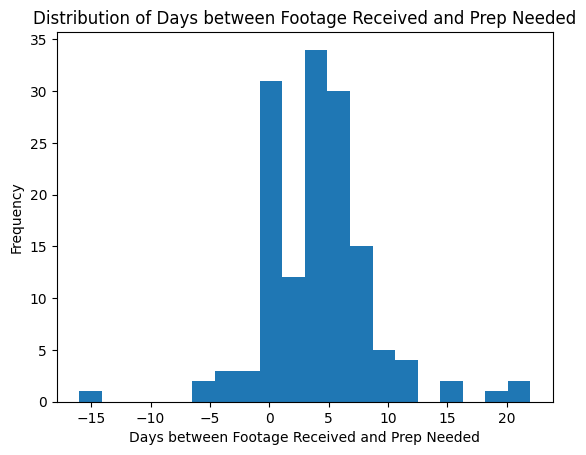

In [84]:
plt.figure(figsize=(10, 6))
post_since_jan.hist(column='Days between Footage Rcvd and Prep Needed', bins=20, grid=False)
plt.title('Distribution of Days between Footage Received and Prep Needed')
plt.xlabel('Days between Footage Received and Prep Needed')
plt.ylabel('Frequency')
plt.show()

## Analysis of footage received on time, late, or early

In [85]:
received_on_time = post_since_jan[post_since_jan['When Will Footage Be Received by Post'] == post_since_jan['Date Footage Actually Received']]
received_on_time.groupby('Series').size()

Series
A Walk With                      4
Bloomberg Investigates          24
Development                      5
Francine Lacqua                  1
Leaders with Francine Lacqua     2
Microdoc                        18
Post Human                       7
Primer                           2
Shorts                          13
The Circuit                      5
The Deal                         2
dtype: int64

In [86]:
received_late = post_since_jan[post_since_jan['When Will Footage Be Received by Post'] < post_since_jan['Date Footage Actually Received']]
received_late.groupby('Series').size()

Series
A Walk With                      2
Bloomberg Investigates          18
Development                      1
Leaders with Francine Lacqua     1
Microdoc                         5
Not Found                        1
Post Human                       2
Primer                           2
Shorts                          11
The Circuit                      4
The Deal                         4
dtype: int64

In [87]:
received_early = post_since_jan[post_since_jan['When Will Footage Be Received by Post'] > post_since_jan['Date Footage Actually Received']]
received_early.groupby('Series').size()

Series
Bloomberg Investigates    4
Francine Lacqua           1
Microdoc                  1
Post Human                1
Shorts                    3
The Circuit               2
dtype: int64

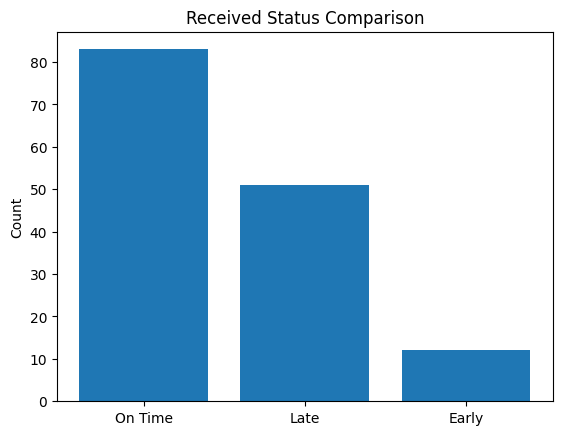

In [88]:
labels = ["On Time", "Late", "Early"]
values = [received_on_time, received_late, received_early]

plt.bar(labels, [v.groupby('Series').size().sum() for v in values])
plt.ylabel("Count")
plt.title("Received Status Comparison")
plt.show()


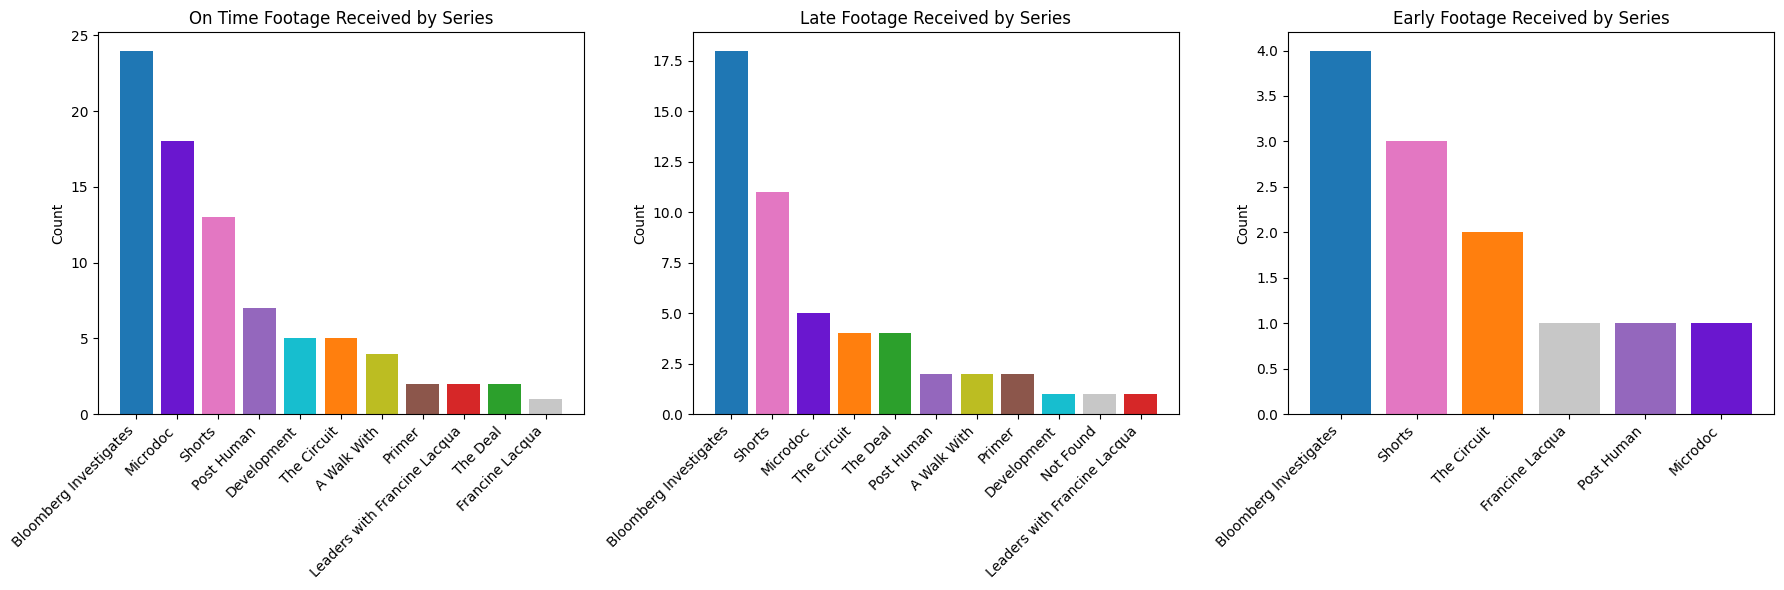

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
dataframes = [received_on_time, received_late, received_early]
labels = ["On Time", "Late", "Early"]

warnings.filterwarnings("ignore", category=UserWarning)

for ax, df, label in zip(axes, dataframes, labels):
    counts = df.groupby('Series').size().sort_values(ascending=False)
    ax.bar(counts.index, 
        counts.values, 
        
        label=label, 
        color=[show_color_palette.get(series, "#c7c7c7") for series in counts.index])
    ax.set_ylabel("Count")
    ax.set_title(f"{label} Footage Received by Series")
    ax.set_xticklabels(counts.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Timeline of shoot dates

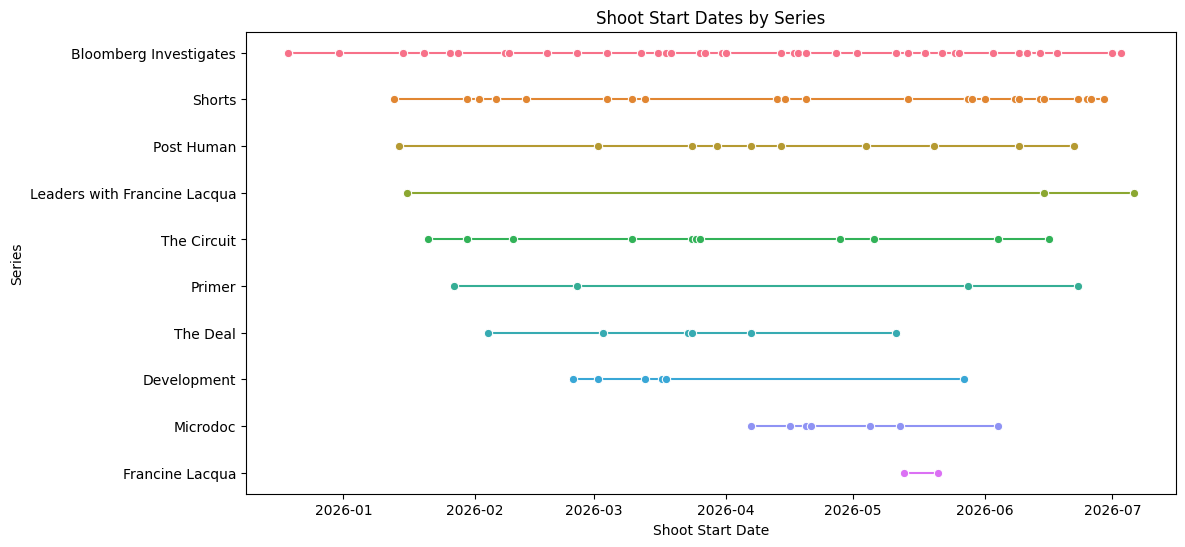

In [91]:
df = post_since_jan.sort_values("Shoot Start Date")
drop_series = ["Not Found"]  # add others if needed

df = df[~df['Series'].isin(drop_series)]
# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df, x="Shoot Start Date", y="Series", hue="Series", estimator=None, marker="o", legend=False
)
plt.title("Shoot Start Dates by Series")
plt.xlabel("Shoot Start Date")
plt.ylabel("Series")

plt.show()


## Average Prep Time Per Series

In [94]:
avg_prep_time_by_series = post_since_jan.groupby("Series")["Days it took to Prep"].mean().sort_values(ascending=False)
print(avg_prep_time_by_series)

Series
Post Human                           6.4
Francine Lacqua                      5.5
Leaders with Francine Lacqua         5.0
Not Found                            5.0
Shorts                          4.222222
Bloomberg Investigates          3.933333
Microdoc                        3.541667
A Walk With                     3.333333
The Deal                        2.833333
Primer                              2.75
Development                     2.666667
The Circuit                     2.363636
Name: Days it took to Prep, dtype: Float64


In [95]:
bloomberg_investigates_df = post_since_jan[post_since_jan["Series"] == "Bloomberg Investigates"]
bloomberg_investigates_df.head()

,Series,Episode,Shoot ID,Who is Prepping,Shoot Dates,Shoot Start Date,Shoot End Date,When Will Footage Be Received by Post,Date Footage Actually Received,When Is Prep Needed By,Date Prep Completed,Days it took to Prep,Total Number of Shoot Days,AE Requests,Timestamp,Email Address,Vertical,Days Between Shoot and Footage,Days between Footage Rcvd and Prep Needed
111,Bloomberg Investigates,OG_BBI_027_Immigration,"OG_BBI_027_Immigration_Portland, OR_19Dec2025",Nancy,2026-01-04 04:02:22.574257429,2025-12-19,2025-12-20,2025-12-22,2026-01-09,2026-01-05,2026-01-12,3,2,"Stringouts, Transcripts For Verite",2025-12-19 13:33:35,a.avila00@gmail.com,Long Form,21.0,-4.0
115,Bloomberg Investigates,OG_BBI_027_Immigration,"OG_BBI_027_Immigration_Portland, OR_31Dec2025",Nancy,2025-12-31 00:00:00.000000000,2025-12-31,2025-12-31,2026-01-03,2026-01-09,2026-01-09,2026-01-12,3,1,"Stringouts, Transcripts For Verite",2025-12-31 17:28:58,a.avila00@gmail.com,Long Form,9.0,0.0
117,Bloomberg Investigates,OG_BBI_032_AirplaneThief,OG_BBI_032_AirplaneThief_Beijing_07Jan2026,Nancy,2026-01-07 00:00:00.000000000,2025-12-19,2026-01-07,2026-01-09,2026-01-09,2026-01-09,2026-01-09,1,1,Stringouts,2025-12-10 13:39:31,ajeffries16@bloomberg.net,Long Form,21.0,0.0
120,Bloomberg Investigates,OG_BBI_023_MongoliaModel,"OG_BBI_023_MongoliaModel_Ulaanbaatar, Mongolia...",Nancy,2026-01-15 04:02:22.574257429,2026-01-15,2026-01-16,2026-01-22,2026-01-20,2026-01-28,2026-01-21,1,2,Stringouts,2026-01-08 03:40:53,vfeng6@bloomberg.net,Long Form,5.0,8.0
123,Bloomberg Investigates,OG_BBI_023_MongoliaModel,OG_BBI_023_MongoliaModel_Kuala Lumpur _20Jan2026,Nancy,2026-01-20 00:00:00.000000000,2026-01-20,2026-01-20,2026-01-23,2026-01-21,2026-01-29,2026-01-22,1,1,"Stringouts, Transcripts For Interview, Will hi...",2026-01-14 21:45:59,vfeng6@bloomberg.net,Long Form,1.0,8.0


In [166]:
bloomberg_investigates_df.groupby("Episode")["Days it took to Prep"].mean().sort_values(ascending=False)

Episode
OG_BBI_045_Metropolis           12.0
BBI_039_USAID                    7.0
OG_BBI_037_BRA_Sugarcane         6.0
OG_BBI_041_Myanmar               5.5
OG_BBI_023_MongoliaModel         4.8
OG_BBI_038_LundinOil           4.625
OG_BBI_040_RussiaMissile        4.25
OG_BBI_027_Immigration      3.142857
OG_BBI_039_USAID                 3.0
OG_BBI_042_HKFire                3.0
OG_BBI_047_BrazilDrones          3.0
OG_BBI_032_AirplaneThief         1.0
OG_BBI_034_RussiaDisinfo         1.0
OG_BBI_044_IllegalSand           1.0
Name: Days it took to Prep, dtype: Float64

In [98]:
plotly_barplots(bloomberg_investigates_df.groupby("Episode")["Days it took to Prep"].mean().reset_index(name="Average Days to Prep"), 'Episode', 'Average Days to Prep', show_color_palette)

In [106]:
post_since_jan.loc[:, "week"] = (
    post_since_jan["Shoot Start Date"].dt.to_period("W").dt.start_time
)

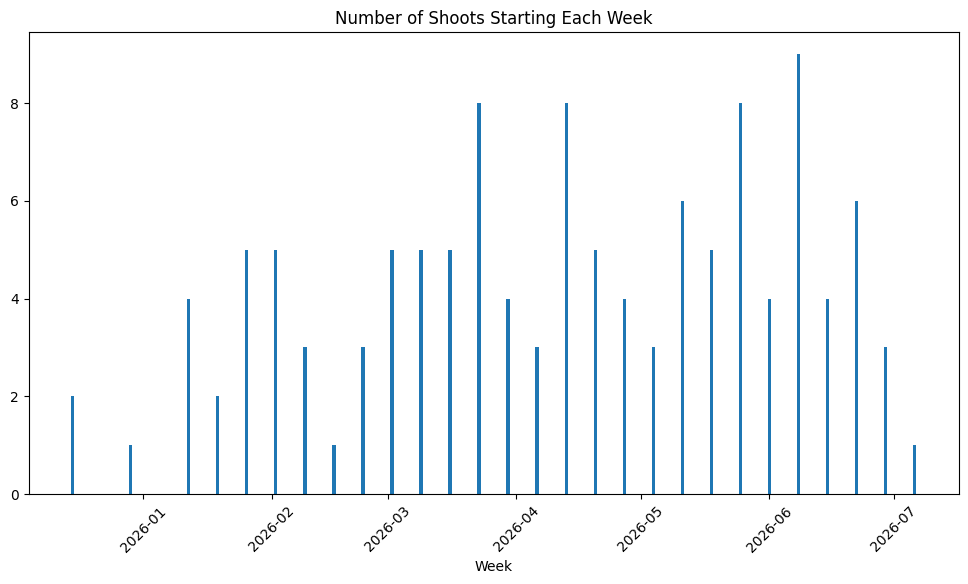

In [107]:
plt.figure(figsize=(12, 6))
plt.bar(post_since_jan.groupby('week').size().index, post_since_jan.groupby('week').size().values)
plt.xlabel("Week")  
plt.xticks(rotation=45)
plt.title("Number of Shoots Starting Each Week")
plt.show()

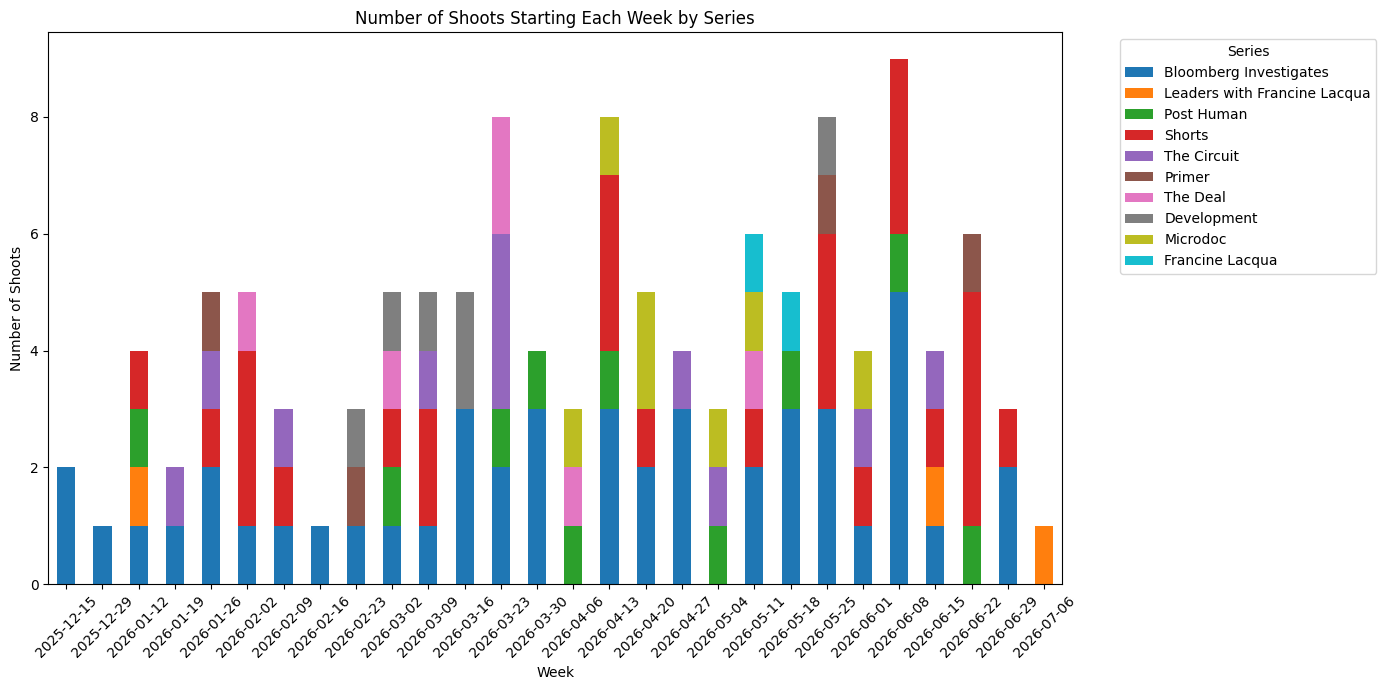

In [108]:
# Group by both 'week' and 'Series', then unstack to get a table suitable for plotting
weekly_series_counts = (
    post_since_jan.groupby(["week", "Series"]).size().unstack(fill_value=0)
)

plt.figure(figsize=(14, 7))
weekly_series_counts.plot(kind="bar", stacked=True, colormap="tab10", ax=plt.gca())
plt.xlabel("Week")
plt.ylabel("Number of Shoots")
plt.title("Number of Shoots Starting Each Week by Series")
plt.xticks(
    ticks=range(len(weekly_series_counts.index)),
    labels=[d.strftime("%Y-%m-%d") for d in weekly_series_counts.index],
    rotation=45,
)
plt.legend(title="Series", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [109]:
weekly_series_counts.head()

Series,Bloomberg Investigates,Leaders with Francine Lacqua,Post Human,Shorts,The Circuit,Primer,The Deal,Development,Microdoc,Francine Lacqua
week,,,,,,,,,,
2025-12-15,2,0,0,0,0,0,0,0,0,0
2025-12-29,1,0,0,0,0,0,0,0,0,0
2026-01-12,1,1,1,1,0,0,0,0,0,0
2026-01-19,1,0,0,0,1,0,0,0,0,0
2026-01-26,2,0,0,1,1,1,0,0,0,0


In [110]:
weekly_series_counts.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 28 entries, 2025-12-15 to 2026-07-06
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Bloomberg Investigates        28 non-null     int64
 1   Leaders with Francine Lacqua  28 non-null     int64
 2   Post Human                    28 non-null     int64
 3   Shorts                        28 non-null     int64
 4   The Circuit                   28 non-null     int64
 5   Primer                        28 non-null     int64
 6   The Deal                      28 non-null     int64
 7   Development                   28 non-null     int64
 8   Microdoc                      28 non-null     int64
 9   Francine Lacqua               28 non-null     int64
dtypes: int64(10)
memory usage: 2.4 KB


In [175]:
weekly_series_counts.describe()

Series,Bloomberg Investigates,Leaders with Francine Lacqua,Post Human,The Circuit,Primer,Shorts,The Deal,Development,Microdoc,Francine Lacqua
count,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000
mean,1.607143,0.071429,0.357143,0.357143,0.142857,0.857143,0.214286,0.214286,0.250000,0.071429
std,1.227442,0.262265,0.487950,0.558721,0.356348,1.238706,0.498675,0.498675,0.518188,0.262265
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.250000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,5.000000,1.000000,1.000000,2.000000,1.000000,4.000000,2.000000,2.000000,2.000000,1.000000
